In [ ]:
# import all required libraries
import sys, os
import numpy as np
import pandas as pd
import random
from random import shuffle, choice
import time
import os
import glob
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import backend as K
from tensorflow.keras.layers import *
from tensorflow.keras.optimizers import *
from tensorflow.keras.models import load_model
from tensorflow.keras import regularizers
from random import shuffle, choice
from sklearn.preprocessing import MinMaxScaler
import sklearn.metrics as metrics
from sklearn.metrics import log_loss
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.models import Model
from sklearn.preprocessing import MinMaxScaler,StandardScaler

# define a function to build a CNN for the SNP data.
def create_cnn(xtest, regularizer=None):
  # obtain the input dimensions.
  inputShape = (xtest.shape[1], xtest.shape[2])
  inputs = Input(shape=inputShape)
  x = inputs
  # first convolutional layer, remember to remove bias if you are intercalating with batch normalization.
  x = Conv1D(256, kernel_size=3, activation='relu', use_bias=False)(x)
  # batch normalization.
  x = BatchNormalization()(x)
  # second layer.
  x = Conv1D(256, kernel_size=3, use_bias=False, activation='relu')(x)
  x = BatchNormalization()(x)
  # third layer.
  x = Conv1D(256, kernel_size=3, use_bias=False, activation='relu')(x)
  x = BatchNormalization()(x)
  # pool the CNN outputs.
  x = GlobalMaxPooling1D()(x)
  # this part is similar to the MLP, a fully connected neural network. We intercalated with dropout to reduce overfitting.
  x = Dense(128, activation='relu')(x)
  # dropout.
  x = Dropout(0.5)(x)
  # second layer of the fully connected neural network.
  x = Dense(128, activation='relu')(x)
  x = Dropout(0.5)(x)
  # third layer of the fully connected neural network. This one matches the number of nodes coming out of the MLP.
  x = Dense(64, activation='relu')(x)
  # Construct the CNN
  #x = BatchNormalization()(x)#Not working very well
  #x = LayerNormalization()(x)#Better?
  model = Model(inputs, x)
  # Return the CNN
  return model

class GatedConcatenate(Layer):
    """
    Applies a trainable or fixed gate (weight) to each input branch
    before concatenating them.
    
    Args:
        initial_traits_weight (float): The starting weight for the first input (traits).
                                     Must be between 0 and 1. The weight for the
                                     second input (SNPs) will be (1 - this value).
        trainable_gates (bool): If True, the model can learn to adjust these
                                weights. If False, the weights are fixed.
    """
    def __init__(self, initial_traits_weight, trainable_gates=True, **kwargs):
        super(GatedConcatenate, self).__init__(**kwargs)
        if not (0 <= initial_traits_weight <= 1):
            raise ValueError("initial_traits_weight must be between 0 and 1.")
            
        self.initial_weights = [initial_traits_weight, 1.0 - initial_traits_weight]
        self.trainable_gates = trainable_gates

    def build(self, input_shape):
        # Create the gate variables. They are shaped for broadcasting across the features.
        self.gates = self.add_weight(
            name='gates',
            shape=(1, len(input_shape)), # Shape will be (1, 2)
            initializer=tf.constant_initializer(self.initial_weights),
            trainable=self.trainable_gates,
            dtype=tf.float32
        )
        super(GatedConcatenate, self).build(input_shape)

    def call(self, inputs):
        if not isinstance(inputs, list) or len(inputs) != 2:
            raise ValueError("GatedConcatenate expects a list of exactly two input tensors.")
        
        # Apply the gates (weights) to each branch using element-wise multiplication
        gated_traits = inputs[0] * self.gates[0, 0]
        gated_snps = inputs[1] * self.gates[0, 1]
        
        # Concatenate the scaled branches
        return Concatenate()([gated_traits, gated_snps])

    def get_config(self):
        # Needed for saving/loading the model
        config = super().get_config()
        config.update({
            'initial_traits_weight': self.initial_weights[0],
            'trainable_gates': self.trainable_gates,
        })
        return config
    
def gated_contributions(model, layer_name=None, labels=("traits", "SNPs")):
    # 1) find the layer
    gated_layer = model.get_layer('gated_concatenate')
    weights = gated_layer.get_weights()[0][0]
    rel_weight = np.sum(np.abs(weights))
    print(f"Final learned weights: Traits={weights[0]/rel_weight:.4f}, SNPs={weights[1]/rel_weight:.4f}")

In [ ]:
## define variables that will be used to train all networks.
# size of the minibatches containing simulations are passed through the network in each epoch.
batch_size = 256
# number of training iterations (epochs) for the SNP only and the combined networks.
epochs = 100
# number of scenarios being classified.
num_classes = 3

# load the traits simulated under the BM model for the 3 scenarios.
traits_BM = np.loadtxt("./traits/traits_BM.txt").reshape(30000,-1,100)
#traits_BM=np.concatenate((traits_BM_full[0:1000],traits_BM_full[10000:11000],traits_BM_full[20000:21000]),axis=0)
#del(traits_BM_full)
# standard scale the continuous (BM) traits
scalers_BM = {}
for i in range(traits_BM.shape[2]):
    scalers_BM[i] = StandardScaler(copy=False)
    traits_BM[:, :, i] = scalers_BM[i].fit_transform(traits_BM[:, :, i]) 

# load the SNPs simulated for the 3 scenarios. 
u1 = np.load("./trainingSims/Model_1sp.npz",mmap_mode='r')
u2 = np.load("./trainingSims/Model_2sp.npz",mmap_mode='r')
u3 = np.load("./trainingSims/Model_3sp.npz",mmap_mode='r')

# combine the loaded SNPs in a single NumPy array.
X=np.concatenate((u1['Model_1sp'],u2['Model_2sp'],u3['Model_3sp']),axis=0)

# transform SNP major alleles in -1 and minor in 1.
for arr,array in enumerate(X):
    for idx,row in enumerate(array):
        if np.count_nonzero(row) > len(row)/2:
            X[arr][idx][X[arr][idx] == 1] = -1
            X[arr][idx][X[arr][idx] == 0] = 1
        else:
            X[arr][idx][X[arr][idx] == 0] = -1

# create a label vector in the same order as the simulations.
y=[0 for i in range(len(u1['Model_1sp']))]
y.extend([1 for i in range(len(u2['Model_2sp']))])
y.extend([2 for i in range(len(u3['Model_3sp']))])
y = np.array(y)

# make sure labels, SNP and traits matrices all have the same length.
print (len(y), len(X), len(traits_BM))

30000 30000 30000


In [ ]:
################################################################################################################################################
# We will start with traits simulated under the BM model.
################################################################################################################################################

# Since we will run the analysis on several subsets, define a function for training on each data subsets (Combined datasets, SNP only and BM traits only).

# function to train on the combined datasets
def combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_BM_train=np.swapaxes(traits_BM_train, 1, 2)
    traits_BM_test=np.swapaxes(traits_BM_test, 1, 2)
    # Create the two CNNs and the combined models
    traits = create_cnn(traits_BM_train)
    snps = create_cnn(xtrain)

    # Use the gated concatenation layer. Start with an 50/50 contribution for each branch, but let the model learn.
    # To set pre-defined weights for each branch, change here  the "initial_traits_weight" to define the traits relative contribution (from 0 to 1).
    # To keep the weight of each branch fixed, change "trainable_gates" to false.
    combinedInput = GatedConcatenate(
        initial_traits_weight=0.5, 
        trainable_gates=True,
        name="gated_concatenate"
    )([traits.output, snps.output])

    # The final fully-connected layer head will have two dense layers (one relu and one softmax)
    x = Dense(64, activation="relu")(combinedInput)

    x = Dense(num_classes, activation="softmax")(x)

    # The final model accepts numerical data on the MLP input and images on the CNN input, outputting a single value
    model = Model(inputs=[traits.input, snps.input], outputs=x)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())
    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit([traits_BM_train, xtrain], ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=([traits_BM_test, xtest], ytest),callbacks=[earlyStopping])

    # Get contributions from each branch.
    gated_contributions(model)
    print (f'Time: {time.time() - start}')

    return model

# function to train on the SNP only datasets
def SNP_subset(ytrain, ytest, xtrain, xtest):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]

    # Create the the CNN 
    snps = create_cnn(xtest)
    
    #Create the last layer for the SNP network
    xSNP = Dense(num_classes, activation="softmax")(snps.output)
    model = Model(inputs=snps.input, outputs=xSNP)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit(xtrain, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(xtest, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')
    
    return model

# function to train on the BM trait only datasets
def BM_subset(ytrain, ytest, traits_BM_train, traits_BM_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_BM_train=np.swapaxes(traits_BM_train, 1, 2)
    traits_BM_test=np.swapaxes(traits_BM_test, 1, 2)
    trait = create_cnn(traits_BM_train)
    
    #Create the last layer for the traits network
    xTRAIT = Dense(num_classes, activation="softmax")(trait.output)
    model = Model(inputs=trait.input, outputs=xTRAIT)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)
    # fit the model and record running times
    start = time.time()
    model.fit(traits_BM_train, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(traits_BM_test, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')

    return model

In [50]:
################################################################################################################################################
#Combined 100 BM, 1K SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X,traits_BM,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save('./Trained_Models/Trained_Comb_Model_100BM_1KSNPs.mod')

Model: "model_23"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_15 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_16 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_42 (Conv1D)              (None, 98, 256)      23040       input_15[0][0]                   
__________________________________________________________________________________________________
conv1d_45 (Conv1D)              (None, 998, 256)     46080       input_16[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 22s 248ms/step - loss: 0.0066 - accuracy: 0.9984 - val_loss: 1.8197e-04 - val_accuracy: 1.0000
Epoch 15/100
88/88 [==============================] - 22s 248ms/step - loss: 0.0066 - accuracy: 0.9984 - val_loss: 1.1859e-04 - val_accuracy: 1.0000
Epoch 16/100
88/88 [==============================] - 22s 248ms/step - loss: 0.0059 - accuracy: 0.9983 - val_loss: 9.3730e-05 - val_accuracy: 1.0000
Epoch 17/100
88/88 [==============================] - 22s 248ms/step - loss: 0.0055 - accuracy: 0.9986 - val_loss: 9.3524e-05 - val_accuracy: 1.0000
Epoch 18/100
88/88 [==============================] - 22s 248ms/step - loss: 0.0046 - accuracy: 0.9988 - val_loss: 5.8964e-05 - val_accuracy: 1.0000
Epoch 19/100
88/88 [==============================] - 22s 248ms/step - loss: 0.0042 - accuracy: 0.9989 - val_loss: 4.5719e-05 - val_accuracy: 1.0000
Epoch 20/100
88/88 [==============================] - 22s 247ms/step - loss: 0.0046 - accuracy: 0.9988 - v

In [51]:
################################################################################################################################################
#1K SNPs only
################################################################################################################################################
# now repeat the analysis only for SNPs
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X,traits_BM,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = SNP_subset(ytrain, ytest, xtrain, xtest)

# save the model
model.save('./Trained_Models/Trained_CNN_Model_1KSNPs.mod')

Model: "model_25"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_17 (InputLayer)        [(None, 1000, 60)]        0         
_________________________________________________________________
conv1d_48 (Conv1D)           (None, 998, 256)          46080     
_________________________________________________________________
batch_normalization_48 (Batc (None, 998, 256)          1024      
_________________________________________________________________
conv1d_49 (Conv1D)           (None, 996, 256)          196608    
_________________________________________________________________
batch_normalization_49 (Batc (None, 996, 256)          1024      
_________________________________________________________________
conv1d_50 (Conv1D)           (None, 994, 256)          196608    
_________________________________________________________________
batch_normalization_50 (Batc (None, 994, 256)          102

In [4]:
################################################################################################################################################
#100 BM
################################################################################################################################################
# now repeat the analysis only for traits
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, yval, traits_BM_train, traits_BM_test  = train_test_split(y,traits_BM,test_size=0.25, shuffle=True,stratify=y)


# train the network
model = BM_subset(ytrain, yval, traits_BM_train, traits_BM_test)

# save the model
model.save('./Trained_Models/Trained_Traits_Model_100BM.mod')

Model: "model_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         [(None, 100, 30)]         0         
_________________________________________________________________
conv1d (Conv1D)              (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization (BatchNo (None, 98, 256)           1024      
_________________________________________________________________
conv1d_1 (Conv1D)            (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_1 (Batch (None, 96, 256)           1024      
_________________________________________________________________
conv1d_2 (Conv1D)            (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_2 (Batch (None, 94, 256)           1024

Epoch 43/100
88/88 [==============================] - 1s 17ms/step - loss: 0.0031 - accuracy: 0.9992 - val_loss: 0.0092 - val_accuracy: 0.9987
Epoch 44/100
88/88 [==============================] - 2s 17ms/step - loss: 0.0035 - accuracy: 0.9990 - val_loss: 0.0096 - val_accuracy: 0.9985
Epoch 45/100
88/88 [==============================] - 1s 17ms/step - loss: 0.0032 - accuracy: 0.9993 - val_loss: 0.0084 - val_accuracy: 0.9985
Epoch 46/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0034 - accuracy: 0.9993 - val_loss: 0.0092 - val_accuracy: 0.9987
Epoch 47/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0031 - accuracy: 0.9992 - val_loss: 0.0093 - val_accuracy: 0.9985
Epoch 48/100
88/88 [==============================] - 2s 17ms/step - loss: 0.0025 - accuracy: 0.9995 - val_loss: 0.0098 - val_accuracy: 0.9987
Epoch 49/100
88/88 [==============================] - 2s 17ms/step - loss: 0.0029 - accuracy: 0.9992 - val_loss: 0.0091 - val_accuracy: 0.9987

In [5]:
################################################################################################################################################
#100 BM, 50 SNPs
################################################################################################################################################
# subset the SNPs
X50=X[:,0:50,:]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X50,traits_BM,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_100BM_50SNPs.mod')

Model: "model_4"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_2 (InputLayer)            [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_3 (InputLayer)            [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_3 (Conv1D)               (None, 98, 256)      23040       input_2[0][0]                    
__________________________________________________________________________________________________
conv1d_6 (Conv1D)               (None, 48, 256)      46080       input_3[0][0]                    
____________________________________________________________________________________________

88/88 [==============================] - 3s 29ms/step - loss: 0.0139 - accuracy: 0.9960 - val_loss: 0.0058 - val_accuracy: 0.9977
Epoch 15/100
88/88 [==============================] - 3s 29ms/step - loss: 0.0121 - accuracy: 0.9964 - val_loss: 0.0049 - val_accuracy: 0.9979
Epoch 16/100
88/88 [==============================] - 3s 29ms/step - loss: 0.0126 - accuracy: 0.9960 - val_loss: 0.0047 - val_accuracy: 0.9980
Epoch 17/100
88/88 [==============================] - 3s 29ms/step - loss: 0.0105 - accuracy: 0.9972 - val_loss: 0.0045 - val_accuracy: 0.9983
Epoch 18/100
88/88 [==============================] - 3s 31ms/step - loss: 0.0090 - accuracy: 0.9976 - val_loss: 0.0042 - val_accuracy: 0.9983
Epoch 19/100
88/88 [==============================] - 3s 29ms/step - loss: 0.0080 - accuracy: 0.9981 - val_loss: 0.0041 - val_accuracy: 0.9984
Epoch 20/100
88/88 [==============================] - 3s 29ms/step - loss: 0.0089 - accuracy: 0.9978 - val_loss: 0.0040 - val_accuracy: 0.9985
Epoch 21/100

In [6]:
################################################################################################################################################
#50 SNPs
################################################################################################################################################
# now repeat the analysis only for SNPs
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest  = train_test_split(y,X50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = SNP_subset(ytrain, ytest, xtrain, xtest)

# save the model
model.save(filepath='./Trained_Models/Trained_CNN_Model_50SNPs.mod')

Model: "model_6"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_4 (InputLayer)         [(None, 50, 60)]          0         
_________________________________________________________________
conv1d_9 (Conv1D)            (None, 48, 256)           46080     
_________________________________________________________________
batch_normalization_9 (Batch (None, 48, 256)           1024      
_________________________________________________________________
conv1d_10 (Conv1D)           (None, 46, 256)           196608    
_________________________________________________________________
batch_normalization_10 (Batc (None, 46, 256)           1024      
_________________________________________________________________
conv1d_11 (Conv1D)           (None, 44, 256)           196608    
_________________________________________________________________
batch_normalization_11 (Batc (None, 44, 256)           1024

Time: 82.67528772354126
INFO:tensorflow:Assets written to: ./Trained_Models/Trained_CNN_Model_50SNPs.mod/assets


In [7]:
################################################################################################################################################
#50 BM, 50 SNPs
################################################################################################################################################
# subset the traits
traits_BM50=traits_BM[:,:,0:50]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X50,traits_BM50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_50BM_50SNPs.mod')

Model: "model_9"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_5 (InputLayer)            [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_6 (InputLayer)            [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_12 (Conv1D)              (None, 48, 256)      23040       input_5[0][0]                    
__________________________________________________________________________________________________
conv1d_15 (Conv1D)              (None, 48, 256)      46080       input_6[0][0]                    
____________________________________________________________________________________________

88/88 [==============================] - 2s 18ms/step - loss: 0.0184 - accuracy: 0.9947 - val_loss: 0.0045 - val_accuracy: 0.9984
Epoch 15/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0157 - accuracy: 0.9954 - val_loss: 0.0042 - val_accuracy: 0.9989
Epoch 16/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0158 - accuracy: 0.9955 - val_loss: 0.0037 - val_accuracy: 0.9989
Epoch 17/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0142 - accuracy: 0.9961 - val_loss: 0.0037 - val_accuracy: 0.9988
Epoch 18/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0111 - accuracy: 0.9967 - val_loss: 0.0041 - val_accuracy: 0.9985
Epoch 19/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0120 - accuracy: 0.9960 - val_loss: 0.0042 - val_accuracy: 0.9984
Epoch 20/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0091 - accuracy: 0.9974 - val_loss: 0.0033 - val_accuracy: 0.9989
Epoch 21/100

In [8]:
################################################################################################################################################
#50 BM
################################################################################################################################################
# now repeat the analysis only for traits
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_BM_train, traits_BM_test  = train_test_split(y,traits_BM50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = BM_subset(ytrain, ytest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Traits_Model_50BM.mod')

Model: "model_11"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_7 (InputLayer)         [(None, 50, 30)]          0         
_________________________________________________________________
conv1d_18 (Conv1D)           (None, 48, 256)           23040     
_________________________________________________________________
batch_normalization_18 (Batc (None, 48, 256)           1024      
_________________________________________________________________
conv1d_19 (Conv1D)           (None, 46, 256)           196608    
_________________________________________________________________
batch_normalization_19 (Batc (None, 46, 256)           1024      
_________________________________________________________________
conv1d_20 (Conv1D)           (None, 44, 256)           196608    
_________________________________________________________________
batch_normalization_20 (Batc (None, 44, 256)           102

Time: 84.79470038414001
INFO:tensorflow:Assets written to: ./Trained_Models/Trained_Traits_Model_50BM.mod/assets


In [9]:
################################################################################################################################################
#50 BM, 10 SNPs
################################################################################################################################################

# subset the SNPs
X10=X[:,0:10,:]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X10,traits_BM50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_50BM_10SNPs.mod')

Model: "model_14"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_8 (InputLayer)            [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_9 (InputLayer)            [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_21 (Conv1D)              (None, 48, 256)      23040       input_8[0][0]                    
__________________________________________________________________________________________________
conv1d_24 (Conv1D)              (None, 8, 256)       46080       input_9[0][0]                    
___________________________________________________________________________________________

88/88 [==============================] - 1s 14ms/step - loss: 0.0319 - accuracy: 0.9901 - val_loss: 0.0194 - val_accuracy: 0.9940
Epoch 15/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0309 - accuracy: 0.9902 - val_loss: 0.0184 - val_accuracy: 0.9943
Epoch 16/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0282 - accuracy: 0.9922 - val_loss: 0.0178 - val_accuracy: 0.9947
Epoch 17/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0247 - accuracy: 0.9925 - val_loss: 0.0179 - val_accuracy: 0.9949
Epoch 18/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0195 - accuracy: 0.9947 - val_loss: 0.0175 - val_accuracy: 0.9951
Epoch 19/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0181 - accuracy: 0.9944 - val_loss: 0.0180 - val_accuracy: 0.9953
Epoch 20/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0190 - accuracy: 0.9951 - val_loss: 0.0170 - val_accuracy: 0.9955
Epoch 21/100

In [10]:
################################################################################################################################################
#10 SNPs
################################################################################################################################################
# now repeat the analysis only for SNPs
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest  = train_test_split(y,X10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = SNP_subset(ytrain, ytest, xtrain, xtest)

# save the model
model.save(filepath='./Trained_Models/Trained_CNN_Model_10SNPs.mod')

Model: "model_16"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_10 (InputLayer)        [(None, 10, 60)]          0         
_________________________________________________________________
conv1d_27 (Conv1D)           (None, 8, 256)            46080     
_________________________________________________________________
batch_normalization_27 (Batc (None, 8, 256)            1024      
_________________________________________________________________
conv1d_28 (Conv1D)           (None, 6, 256)            196608    
_________________________________________________________________
batch_normalization_28 (Batc (None, 6, 256)            1024      
_________________________________________________________________
conv1d_29 (Conv1D)           (None, 4, 256)            196608    
_________________________________________________________________
batch_normalization_29 (Batc (None, 4, 256)            102

Time: 68.7216100692749
INFO:tensorflow:Assets written to: ./Trained_Models/Trained_CNN_Model_10SNPs.mod/assets


In [11]:
################################################################################################################################################
#10 BM
################################################################################################################################################
# subset the traits
traits_BM10=traits_BM[:,:,0:10]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_BM_train, traits_BM_test  = train_test_split(y,traits_BM10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = BM_subset(ytrain, ytest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Traits_Model_10BM.mod')

Model: "model_18"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_11 (InputLayer)        [(None, 10, 30)]          0         
_________________________________________________________________
conv1d_30 (Conv1D)           (None, 8, 256)            23040     
_________________________________________________________________
batch_normalization_30 (Batc (None, 8, 256)            1024      
_________________________________________________________________
conv1d_31 (Conv1D)           (None, 6, 256)            196608    
_________________________________________________________________
batch_normalization_31 (Batc (None, 6, 256)            1024      
_________________________________________________________________
conv1d_32 (Conv1D)           (None, 4, 256)            196608    
_________________________________________________________________
batch_normalization_32 (Batc (None, 4, 256)            102

Time: 68.067706823349
INFO:tensorflow:Assets written to: ./Trained_Models/Trained_Traits_Model_10BM.mod/assets


In [12]:
################################################################################################################################################
#10 SNPS, 10 BM
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]
# now do the combined the analysis
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X10,traits_BM10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_10BM_10SNPs.mod')

Model: "model_21"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_12 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_13 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_33 (Conv1D)              (None, 8, 256)       23040       input_12[0][0]                   
__________________________________________________________________________________________________
conv1d_36 (Conv1D)              (None, 8, 256)       46080       input_13[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 12ms/step - loss: 0.1762 - accuracy: 0.9395 - val_loss: 0.1381 - val_accuracy: 0.9535
Epoch 15/100
88/88 [==============================] - 1s 11ms/step - loss: 0.1602 - accuracy: 0.9440 - val_loss: 0.1330 - val_accuracy: 0.9536
Epoch 16/100
88/88 [==============================] - 1s 12ms/step - loss: 0.1459 - accuracy: 0.9496 - val_loss: 0.1253 - val_accuracy: 0.9580
Epoch 17/100
88/88 [==============================] - 1s 11ms/step - loss: 0.1327 - accuracy: 0.9528 - val_loss: 0.1225 - val_accuracy: 0.9599
Epoch 18/100
88/88 [==============================] - 1s 12ms/step - loss: 0.1196 - accuracy: 0.9584 - val_loss: 0.1154 - val_accuracy: 0.9623
Epoch 19/100
88/88 [==============================] - 1s 12ms/step - loss: 0.1082 - accuracy: 0.9626 - val_loss: 0.1122 - val_accuracy: 0.9645
Epoch 20/100
88/88 [==============================] - 1s 12ms/step - loss: 0.0977 - accuracy: 0.9661 - val_loss: 0.1087 - val_accuracy: 0.9659
Epoch 21/100

In [13]:
################################################################################################################################################
#1KSNPS, 10 BM
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X,traits_BM10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_10BM_1KSNPs.mod')

Model: "model_24"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_14 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_15 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_39 (Conv1D)              (None, 8, 256)       23040       input_14[0][0]                   
__________________________________________________________________________________________________
conv1d_42 (Conv1D)              (None, 998, 256)     46080       input_15[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 20s 231ms/step - loss: 0.0063 - accuracy: 0.9985 - val_loss: 4.5612e-05 - val_accuracy: 1.0000
Epoch 15/100
88/88 [==============================] - 20s 231ms/step - loss: 0.0064 - accuracy: 0.9984 - val_loss: 3.9514e-05 - val_accuracy: 1.0000
Epoch 16/100
88/88 [==============================] - 20s 230ms/step - loss: 0.0051 - accuracy: 0.9985 - val_loss: 2.0417e-05 - val_accuracy: 1.0000
Epoch 17/100
88/88 [==============================] - 20s 230ms/step - loss: 0.0045 - accuracy: 0.9986 - val_loss: 2.7095e-05 - val_accuracy: 1.0000
Epoch 18/100
88/88 [==============================] - 20s 231ms/step - loss: 0.0044 - accuracy: 0.9987 - val_loss: 1.5714e-05 - val_accuracy: 1.0000
Epoch 19/100
88/88 [==============================] - 20s 230ms/step - loss: 0.0030 - accuracy: 0.9996 - val_loss: 3.2836e-05 - val_accuracy: 1.0000
Epoch 20/100
88/88 [==============================] - 20s 230ms/step - loss: 0.0042 - accuracy: 0.9991 - v

In [14]:
################################################################################################################################################
#1KSNPS, 50 BM
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X,traits_BM50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_50BM_1KSNPs.mod')

Model: "model_27"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_16 (InputLayer)           [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_17 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_45 (Conv1D)              (None, 48, 256)      23040       input_16[0][0]                   
__________________________________________________________________________________________________
conv1d_48 (Conv1D)              (None, 998, 256)     46080       input_17[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 21s 238ms/step - loss: 0.0055 - accuracy: 0.9987 - val_loss: 5.5679e-04 - val_accuracy: 0.9999
Epoch 15/100
88/88 [==============================] - 21s 239ms/step - loss: 0.0056 - accuracy: 0.9986 - val_loss: 5.3529e-04 - val_accuracy: 0.9999
Epoch 16/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0055 - accuracy: 0.9987 - val_loss: 5.0575e-04 - val_accuracy: 0.9999
Epoch 17/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0053 - accuracy: 0.9986 - val_loss: 5.4519e-04 - val_accuracy: 0.9999
Epoch 18/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0048 - accuracy: 0.9989 - val_loss: 4.1122e-04 - val_accuracy: 0.9999
Epoch 19/100
88/88 [==============================] - 21s 238ms/step - loss: 0.0040 - accuracy: 0.9988 - val_loss: 4.3707e-04 - val_accuracy: 0.9999
Epoch 20/100
88/88 [==============================] - 21s 238ms/step - loss: 0.0033 - accuracy: 0.9993 - v

In [15]:
################################################################################################################################################
#50SNPS, 10 BM
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X50,traits_BM10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_10BM_50SNPs.mod')

Model: "model_30"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_18 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_19 (InputLayer)           [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_51 (Conv1D)              (None, 8, 256)       23040       input_18[0][0]                   
__________________________________________________________________________________________________
conv1d_54 (Conv1D)              (None, 48, 256)      46080       input_19[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 13ms/step - loss: 0.0227 - accuracy: 0.9937 - val_loss: 0.0112 - val_accuracy: 0.9969
Epoch 15/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0183 - accuracy: 0.9949 - val_loss: 0.0106 - val_accuracy: 0.9972
Epoch 16/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0163 - accuracy: 0.9955 - val_loss: 0.0110 - val_accuracy: 0.9971
Epoch 17/100
88/88 [==============================] - 1s 14ms/step - loss: 0.0163 - accuracy: 0.9954 - val_loss: 0.0108 - val_accuracy: 0.9971
Epoch 18/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0130 - accuracy: 0.9958 - val_loss: 0.0107 - val_accuracy: 0.9975
Epoch 19/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0136 - accuracy: 0.9963 - val_loss: 0.0105 - val_accuracy: 0.9973
Epoch 20/100
88/88 [==============================] - 1s 13ms/step - loss: 0.0109 - accuracy: 0.9971 - val_loss: 0.0105 - val_accuracy: 0.9973
Epoch 21/100

In [16]:
################################################################################################################################################
#10 SNPS, 100 BM
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test  = train_test_split(y,X10,traits_BM,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_BM_subset(ytrain, ytest, xtrain, xtest, traits_BM_train, traits_BM_test)


# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_100BM_10SNPs.mod')

Model: "model_33"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_20 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_21 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_57 (Conv1D)              (None, 98, 256)      23040       input_20[0][0]                   
__________________________________________________________________________________________________
conv1d_60 (Conv1D)              (None, 8, 256)       46080       input_21[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 2s 20ms/step - loss: 0.0236 - accuracy: 0.9936 - val_loss: 0.0154 - val_accuracy: 0.9967
Epoch 15/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0198 - accuracy: 0.9948 - val_loss: 0.0150 - val_accuracy: 0.9971
Epoch 16/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0176 - accuracy: 0.9949 - val_loss: 0.0145 - val_accuracy: 0.9973
Epoch 17/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0130 - accuracy: 0.9968 - val_loss: 0.0142 - val_accuracy: 0.9975
Epoch 18/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0139 - accuracy: 0.9962 - val_loss: 0.0140 - val_accuracy: 0.9975
Epoch 19/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0142 - accuracy: 0.9963 - val_loss: 0.0138 - val_accuracy: 0.9976
Epoch 20/100
88/88 [==============================] - 2s 20ms/step - loss: 0.0116 - accuracy: 0.9969 - val_loss: 0.0137 - val_accuracy: 0.9976
Epoch 21/100

In [ ]:
################################################################################################################################################
# Now repeat with traits simulated under the OU model.
################################################################################################################################################
# load the traits simulated under the OU model for the 3 scenarios. 
traits_OU = []
traits_OU = np.loadtxt("./traits/traits_OU.txt").reshape(30000,-1,100)
# transform into a NumPy array. 
traits_OU = np.array(traits_OU)

# standard scale the continuous (OU) traits
scalers_OU = {}
for i in range(traits_OU.shape[2]):
    scalers_OU[i] = StandardScaler(copy=False)
    traits_OU[:, :, i] = scalers_OU[i].fit_transform(traits_OU[:, :, i]) 

# load the SNPs simulated for the 3 scenarios. 
u1 = np.load("./trainingSims/Model_1sp.npz",mmap_mode='r')
u2 = np.load("./trainingSims/Model_2sp.npz",mmap_mode='r')
u3 = np.load("./trainingSims/Model_3sp.npz",mmap_mode='r')

# combine the loaded SNPs in a single NumPy array.
X=np.concatenate((u1['Model_1sp'],u2['Model_2sp'],u3['Model_3sp']),axis=0)

#transform major alleles in -1 and minor in 1
for arr,array in enumerate(X):
    for idx,row in enumerate(array):
        if np.count_nonzero(row) > len(row)/2:
            X[arr][idx][X[arr][idx] == 1] = -1
            X[arr][idx][X[arr][idx] == 0] = 1
        else:
            X[arr][idx][X[arr][idx] == 0] = -1
            
# create a label vector in the same order as the simulations.
y=[0 for i in range(len(u1['Model_1sp']))]
y.extend([1 for i in range(len(u2['Model_2sp']))])
y.extend([2 for i in range(len(u3['Model_3sp']))])
y = np.array(y)

# make sure labels, SNP and traits matrices all have the same length.
print (len(X), len(y), len(traits_OU))                                                                                                        # Create the MLP and CNN model

In [ ]:
# Since we will run the analysis on several subsets, define a function for training on each data subsets (Combined datasets, SNP only and OU traits only).

# function to train on the combined datasets
def combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_OU_train=np.swapaxes(traits_OU_train, 1, 2)
    traits_OU_test=np.swapaxes(traits_OU_test, 1, 2)
    # Create the two CNNs and the combined models
    traits = create_cnn(traits_OU_train)
    snps = create_cnn(xtrain)

    # Use the gated concatenation layer. Start with an 50/50 contribution for each branch, but let the model learn.
    # To set pre-defined weights for each branch, change here  the "initial_traits_weight" to define the traits relative contribution (from 0 to 1).
    # To keep the weight of each branch fixed, change "trainable_gates" to false.
    combinedInput = GatedConcatenate(
        initial_traits_weight=0.5, 
        trainable_gates=True,
        name="gated_concatenate"
    )([traits.output, snps.output])

    # The final fully-connected layer head will have two dense layers (one relu and one softmax)
    x = Dense(64, activation="relu")(combinedInput)

    x = Dense(num_classes, activation="softmax")(x)

    # The final model accepts numerical data on the MLP input and images on the CNN input, outputting a single value
    model = Model(inputs=[traits.input, snps.input], outputs=x)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())
    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit([traits_OU_train, xtrain], ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=([traits_OU_test, xtest], ytest),callbacks=[earlyStopping])
    
    # Get contributions from each branch.
    gated_contributions(model)
    print (f'Time: {time.time() - start}')
    
    return model

# function to train on the OU trait only datasets
def OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_OU_train=np.swapaxes(traits_OU_train, 1, 2)
    traits_OU_test=np.swapaxes(traits_OU_test, 1, 2)
    trait = create_cnn(traits_OU_train)

    #Create the last layer for the traits network
    xTRAIT = Dense(num_classes, activation="softmax")(trait.output)
    model = Model(inputs=trait.input, outputs=xTRAIT)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)
    # fit the model and record running times
    start = time.time()
    model.fit(traits_OU_train, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(traits_OU_test, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')
    
    return model

In [19]:
################################################################################################################################################
# Combined 100 OU, 1K SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X,traits_OU,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_100OU_1KSNPs.mod')

Model: "model_36"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_22 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_23 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_63 (Conv1D)              (None, 98, 256)      23040       input_22[0][0]                   
__________________________________________________________________________________________________
conv1d_66 (Conv1D)              (None, 998, 256)     46080       input_23[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 22s 247ms/step - loss: 0.0060 - accuracy: 0.9984 - val_loss: 4.8748e-04 - val_accuracy: 0.9999
Epoch 15/100
88/88 [==============================] - 22s 247ms/step - loss: 0.0063 - accuracy: 0.9985 - val_loss: 4.5105e-04 - val_accuracy: 0.9999
Epoch 16/100
88/88 [==============================] - 22s 246ms/step - loss: 0.0057 - accuracy: 0.9984 - val_loss: 5.3004e-04 - val_accuracy: 0.9999
Epoch 17/100
88/88 [==============================] - 22s 247ms/step - loss: 0.0044 - accuracy: 0.9988 - val_loss: 4.8600e-04 - val_accuracy: 0.9999
Epoch 18/100
88/88 [==============================] - 22s 248ms/step - loss: 0.0039 - accuracy: 0.9989 - val_loss: 4.7253e-04 - val_accuracy: 0.9999
Epoch 19/100
88/88 [==============================] - 22s 250ms/step - loss: 0.0035 - accuracy: 0.9992 - val_loss: 3.8786e-04 - val_accuracy: 0.9999
Epoch 20/100
88/88 [==============================] - 22s 247ms/step - loss: 0.0038 - accuracy: 0.9993 - v

Epoch 69/100
88/88 [==============================] - 22s 245ms/step - loss: 0.0012 - accuracy: 0.9996 - val_loss: 5.0061e-05 - val_accuracy: 1.0000
Epoch 70/100
88/88 [==============================] - 22s 245ms/step - loss: 7.5057e-04 - accuracy: 0.9998 - val_loss: 2.1098e-05 - val_accuracy: 1.0000
Epoch 71/100
88/88 [==============================] - 22s 246ms/step - loss: 7.6281e-04 - accuracy: 0.9998 - val_loss: 1.2955e-05 - val_accuracy: 1.0000
Epoch 72/100
88/88 [==============================] - 22s 247ms/step - loss: 0.0011 - accuracy: 0.9998 - val_loss: 1.5416e-05 - val_accuracy: 1.0000
Epoch 73/100
88/88 [==============================] - 22s 246ms/step - loss: 6.7503e-04 - accuracy: 0.9999 - val_loss: 1.6593e-05 - val_accuracy: 1.0000
Epoch 74/100
88/88 [==============================] - 22s 245ms/step - loss: 8.1414e-04 - accuracy: 0.9998 - val_loss: 1.4622e-05 - val_accuracy: 1.0000
Epoch 75/100
88/88 [==============================] - 22s 245ms/step - loss: 7.6871e-04 - 

In [20]:
################################################################################################################################################
#100 OU
################################################################################################################################################
# now repeat the analysis only for traits
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_OU_train, traits_OU_test  = train_test_split(y,traits_OU,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Traits_Model_100OU.mod')

Model: "model_38"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_24 (InputLayer)        [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_69 (Conv1D)           (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_69 (Batc (None, 98, 256)           1024      
_________________________________________________________________
conv1d_70 (Conv1D)           (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_70 (Batc (None, 96, 256)           1024      
_________________________________________________________________
conv1d_71 (Conv1D)           (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_71 (Batc (None, 94, 256)           102

Epoch 43/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0026 - accuracy: 0.9995 - val_loss: 0.0055 - val_accuracy: 0.9992
Epoch 44/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0034 - accuracy: 0.9991 - val_loss: 0.0054 - val_accuracy: 0.9992
Epoch 45/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0031 - accuracy: 0.9993 - val_loss: 0.0054 - val_accuracy: 0.9992
Epoch 46/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0027 - accuracy: 0.9995 - val_loss: 0.0054 - val_accuracy: 0.9992
Epoch 47/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0026 - accuracy: 0.9995 - val_loss: 0.0052 - val_accuracy: 0.9991
Epoch 48/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0031 - accuracy: 0.9992 - val_loss: 0.0053 - val_accuracy: 0.9992
Epoch 49/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0026 - accuracy: 0.9995 - val_loss: 0.0052 - val_accuracy: 0.9992

In [21]:
################################################################################################################################################
#100 OU, 50 SNPs
################################################################################################################################################
# subset the SNPs
X50=X[:,0:50,:]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X50,traits_OU,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_100OU_50SNPs.mod')

Model: "model_41"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_25 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_26 (InputLayer)           [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_72 (Conv1D)              (None, 98, 256)      23040       input_25[0][0]                   
__________________________________________________________________________________________________
conv1d_75 (Conv1D)              (None, 48, 256)      46080       input_26[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 2s 28ms/step - loss: 0.0131 - accuracy: 0.9967 - val_loss: 0.0058 - val_accuracy: 0.9983
Epoch 15/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0124 - accuracy: 0.9964 - val_loss: 0.0054 - val_accuracy: 0.9984
Epoch 16/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0103 - accuracy: 0.9971 - val_loss: 0.0053 - val_accuracy: 0.9984
Epoch 17/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0098 - accuracy: 0.9976 - val_loss: 0.0052 - val_accuracy: 0.9984
Epoch 18/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0095 - accuracy: 0.9974 - val_loss: 0.0052 - val_accuracy: 0.9985
Epoch 19/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0085 - accuracy: 0.9977 - val_loss: 0.0051 - val_accuracy: 0.9984
Epoch 20/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0083 - accuracy: 0.9978 - val_loss: 0.0051 - val_accuracy: 0.9987
Epoch 21/100

In [22]:
################################################################################################################################################
#50 OU, 50 SNPs
################################################################################################################################################
# subset the traits
traits_OU50=traits_OU[:,:,0:50]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X50,traits_OU50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_50OU_50SNPs.mod')

Model: "model_44"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_27 (InputLayer)           [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_28 (InputLayer)           [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_78 (Conv1D)              (None, 48, 256)      23040       input_27[0][0]                   
__________________________________________________________________________________________________
conv1d_81 (Conv1D)              (None, 48, 256)      46080       input_28[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 17ms/step - loss: 0.0172 - accuracy: 0.9953 - val_loss: 0.0108 - val_accuracy: 0.9967
Epoch 15/100
88/88 [==============================] - 1s 17ms/step - loss: 0.0147 - accuracy: 0.9958 - val_loss: 0.0104 - val_accuracy: 0.9973
Epoch 16/100
88/88 [==============================] - 2s 17ms/step - loss: 0.0139 - accuracy: 0.9960 - val_loss: 0.0096 - val_accuracy: 0.9976
Epoch 17/100
88/88 [==============================] - 1s 17ms/step - loss: 0.0116 - accuracy: 0.9968 - val_loss: 0.0088 - val_accuracy: 0.9975
Epoch 18/100
88/88 [==============================] - 2s 17ms/step - loss: 0.0108 - accuracy: 0.9968 - val_loss: 0.0091 - val_accuracy: 0.9976
Epoch 19/100
88/88 [==============================] - 2s 17ms/step - loss: 0.0104 - accuracy: 0.9971 - val_loss: 0.0101 - val_accuracy: 0.9975
Epoch 20/100
88/88 [==============================] - 2s 17ms/step - loss: 0.0083 - accuracy: 0.9979 - val_loss: 0.0102 - val_accuracy: 0.9975
Epoch 21/100

In [23]:
################################################################################################################################################
#50 OU
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_OU_train, traits_OU_test = train_test_split(y,traits_OU50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Traits_Model_50OU.mod')

Model: "model_46"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_29 (InputLayer)        [(None, 50, 30)]          0         
_________________________________________________________________
conv1d_84 (Conv1D)           (None, 48, 256)           23040     
_________________________________________________________________
batch_normalization_84 (Batc (None, 48, 256)           1024      
_________________________________________________________________
conv1d_85 (Conv1D)           (None, 46, 256)           196608    
_________________________________________________________________
batch_normalization_85 (Batc (None, 46, 256)           1024      
_________________________________________________________________
conv1d_86 (Conv1D)           (None, 44, 256)           196608    
_________________________________________________________________
batch_normalization_86 (Batc (None, 44, 256)           102

Time: 68.08278703689575
INFO:tensorflow:Assets written to: ./Trained_Models/Trained_Traits_Model_50OU.mod/assets


In [25]:
################################################################################################################################################
#50 OU, 10 SNPs
################################################################################################################################################
# subset the SNPs
X10=X[:,0:10,:]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test = train_test_split(y,X10,traits_OU50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_50OU_10SNPs.mod')

Model: "model_49"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_30 (InputLayer)           [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_31 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_87 (Conv1D)              (None, 48, 256)      23040       input_30[0][0]                   
__________________________________________________________________________________________________
conv1d_90 (Conv1D)              (None, 8, 256)       46080       input_31[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 11ms/step - loss: 0.0418 - accuracy: 0.9879 - val_loss: 0.0178 - val_accuracy: 0.9949
Epoch 15/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0348 - accuracy: 0.9902 - val_loss: 0.0151 - val_accuracy: 0.9957
Epoch 16/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0289 - accuracy: 0.9914 - val_loss: 0.0155 - val_accuracy: 0.9956
Epoch 17/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0267 - accuracy: 0.9916 - val_loss: 0.0143 - val_accuracy: 0.9960
Epoch 18/100
88/88 [==============================] - 1s 11ms/step - loss: 0.0229 - accuracy: 0.9928 - val_loss: 0.0144 - val_accuracy: 0.9963
Epoch 19/100
88/88 [==============================] - 1s 11ms/step - loss: 0.0217 - accuracy: 0.9935 - val_loss: 0.0149 - val_accuracy: 0.9961
Epoch 20/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0197 - accuracy: 0.9940 - val_loss: 0.0139 - val_accuracy: 0.9963
Epoch 21/100

In [26]:
################################################################################################################################################
#10 OU
################################################################################################################################################
# subset the traits
traits_OU10=traits_OU[:,:,0:10]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_OU_train, traits_OU_test = train_test_split(y,traits_OU10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = OU_subset(ytrain, ytest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Traits_Model_10OU.mod')

Model: "model_51"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_32 (InputLayer)        [(None, 10, 30)]          0         
_________________________________________________________________
conv1d_93 (Conv1D)           (None, 8, 256)            23040     
_________________________________________________________________
batch_normalization_93 (Batc (None, 8, 256)            1024      
_________________________________________________________________
conv1d_94 (Conv1D)           (None, 6, 256)            196608    
_________________________________________________________________
batch_normalization_94 (Batc (None, 6, 256)            1024      
_________________________________________________________________
conv1d_95 (Conv1D)           (None, 4, 256)            196608    
_________________________________________________________________
batch_normalization_95 (Batc (None, 4, 256)            102

Time: 44.28271222114563
INFO:tensorflow:Assets written to: ./Trained_Models/Trained_Traits_Model_10OU.mod/assets


In [27]:
################################################################################################################################################
#10 SNPS, 10 OU
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X10,traits_OU10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_10OU_10SNPs.mod')

Model: "model_54"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_33 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_34 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_96 (Conv1D)              (None, 8, 256)       23040       input_33[0][0]                   
__________________________________________________________________________________________________
conv1d_99 (Conv1D)              (None, 8, 256)       46080       input_34[0][0]                   
___________________________________________________________________________________________

Epoch 72/100
88/88 [==============================] - 1s 8ms/step - loss: 0.0096 - accuracy: 0.9967 - val_loss: 0.1751 - val_accuracy: 0.9624
Epoch 73/100
88/88 [==============================] - 1s 8ms/step - loss: 0.0087 - accuracy: 0.9975 - val_loss: 0.1810 - val_accuracy: 0.9615
Epoch 74/100
88/88 [==============================] - 1s 8ms/step - loss: 0.0078 - accuracy: 0.9976 - val_loss: 0.1757 - val_accuracy: 0.9633
Epoch 75/100
88/88 [==============================] - 1s 8ms/step - loss: 0.0095 - accuracy: 0.9972 - val_loss: 0.1773 - val_accuracy: 0.9624
Epoch 76/100
88/88 [==============================] - 1s 8ms/step - loss: 0.0066 - accuracy: 0.9983 - val_loss: 0.1742 - val_accuracy: 0.9631
Epoch 77/100
88/88 [==============================] - 1s 8ms/step - loss: 0.0064 - accuracy: 0.9982 - val_loss: 0.1770 - val_accuracy: 0.9628
Epoch 78/100
88/88 [==============================] - 1s 8ms/step - loss: 0.0054 - accuracy: 0.9981 - val_loss: 0.1843 - val_accuracy: 0.9635
Epoch 

In [28]:
################################################################################################################################################
#1K SNPS, 10 OU
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X,traits_OU10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_10OU_1KSNPs.mod')

Model: "model_57"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_35 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_36 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_102 (Conv1D)             (None, 8, 256)       23040       input_35[0][0]                   
__________________________________________________________________________________________________
conv1d_105 (Conv1D)             (None, 998, 256)     46080       input_36[0][0]                   
___________________________________________________________________________________________

In [29]:
################################################################################################################################################
#1K SNPS, 50 OU
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X,traits_OU50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_50OU_1KSNPs.mod')

Model: "model_60"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_37 (InputLayer)           [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_38 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_108 (Conv1D)             (None, 48, 256)      23040       input_37[0][0]                   
__________________________________________________________________________________________________
conv1d_111 (Conv1D)             (None, 998, 256)     46080       input_38[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0054 - accuracy: 0.9988 - val_loss: 2.7091e-05 - val_accuracy: 1.0000
Epoch 15/100
88/88 [==============================] - 21s 238ms/step - loss: 0.0039 - accuracy: 0.9993 - val_loss: 1.7866e-05 - val_accuracy: 1.0000
Epoch 16/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0046 - accuracy: 0.9987 - val_loss: 1.4387e-05 - val_accuracy: 1.0000
Epoch 17/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0041 - accuracy: 0.9989 - val_loss: 1.2533e-05 - val_accuracy: 1.0000
Epoch 18/100
88/88 [==============================] - 21s 236ms/step - loss: 0.0045 - accuracy: 0.9986 - val_loss: 1.1795e-05 - val_accuracy: 1.0000
Epoch 19/100
88/88 [==============================] - 21s 236ms/step - loss: 0.0040 - accuracy: 0.9988 - val_loss: 1.2562e-05 - val_accuracy: 1.0000
Epoch 20/100
88/88 [==============================] - 21s 236ms/step - loss: 0.0033 - accuracy: 0.9992 - v

In [30]:
################################################################################################################################################
#50 SNPS, 10 OU
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X50,traits_OU10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_10OU_50SNPs.mod')

Model: "model_63"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_39 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_40 (InputLayer)           [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_114 (Conv1D)             (None, 8, 256)       23040       input_39[0][0]                   
__________________________________________________________________________________________________
conv1d_117 (Conv1D)             (None, 48, 256)      46080       input_40[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 10ms/step - loss: 0.0184 - accuracy: 0.9950 - val_loss: 0.0088 - val_accuracy: 0.9968
Epoch 15/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0173 - accuracy: 0.9956 - val_loss: 0.0079 - val_accuracy: 0.9969
Epoch 16/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0157 - accuracy: 0.9956 - val_loss: 0.0080 - val_accuracy: 0.9969
Epoch 17/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0151 - accuracy: 0.9958 - val_loss: 0.0076 - val_accuracy: 0.9983
Epoch 18/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0133 - accuracy: 0.9964 - val_loss: 0.0073 - val_accuracy: 0.9983
Epoch 19/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0105 - accuracy: 0.9972 - val_loss: 0.0072 - val_accuracy: 0.9981
Epoch 20/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0099 - accuracy: 0.9973 - val_loss: 0.0069 - val_accuracy: 0.9984
Epoch 21/100

In [31]:
################################################################################################################################################
#10 SNPS, 100 OU
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test  = train_test_split(y,X10,traits_OU,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_OU_subset(ytrain, ytest, xtrain, xtest, traits_OU_train, traits_OU_test)

# save the model
model.save(filepath='./Trained_Models/Trained_Comb_Model_100OU_10SNPs.mod')

Model: "model_66"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_41 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_42 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_120 (Conv1D)             (None, 98, 256)      23040       input_41[0][0]                   
__________________________________________________________________________________________________
conv1d_123 (Conv1D)             (None, 8, 256)       46080       input_42[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 2s 18ms/step - loss: 0.0232 - accuracy: 0.9938 - val_loss: 0.0071 - val_accuracy: 0.9980
Epoch 15/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0218 - accuracy: 0.9939 - val_loss: 0.0075 - val_accuracy: 0.9979
Epoch 16/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0166 - accuracy: 0.9953 - val_loss: 0.0066 - val_accuracy: 0.9984
Epoch 17/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0158 - accuracy: 0.9960 - val_loss: 0.0062 - val_accuracy: 0.9987
Epoch 18/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0155 - accuracy: 0.9956 - val_loss: 0.0056 - val_accuracy: 0.9985
Epoch 19/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0128 - accuracy: 0.9965 - val_loss: 0.0060 - val_accuracy: 0.9980
Epoch 20/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0111 - accuracy: 0.9970 - val_loss: 0.0058 - val_accuracy: 0.9985
Epoch 21/100

In [ ]:
################################################################################################################################################
# Now repeat with discrete traits.
################################################################################################################################################

# load the discrete traits simulated for the 3 scenarios. 
traits_disc = []
traits_disc = np.loadtxt("./traits/traits_disc.txt").reshape(30000,-1,100)
# transform into a NumPy array.
traits_disc = np.array(traits_disc)

# load the SNPs simulated for the 3 scenarios.
u1 = np.load("./trainingSims/Model_1sp.npz",mmap_mode='r')
u2 = np.load("./trainingSims/Model_2sp.npz",mmap_mode='r')
u3 = np.load("./trainingSims/Model_3sp.npz",mmap_mode='r')

# combine the loaded SNPs in a single NumPy array.
X=np.concatenate((u1['Model_1sp'],u2['Model_2sp'],u3['Model_3sp']),axis=0)

#transform major alleles in -1 and minor in 1
for arr,array in enumerate(X):
    for idx,row in enumerate(array):
        if np.count_nonzero(row) > len(row)/2:
            X[arr][idx][X[arr][idx] == 1] = -1
            X[arr][idx][X[arr][idx] == 0] = 1
        else:
            X[arr][idx][X[arr][idx] == 0] = -1
            
# create a label vector in the same order as the simulations.
y=[0 for i in range(len(u1['Model_1sp']))]
y.extend([1 for i in range(len(u2['Model_2sp']))])
y.extend([2 for i in range(len(u3['Model_3sp']))])
y = np.array(y)

# make sure labels, SNP and traits matrices all have the same length.
print (len(X), len(y), len(traits_disc))

In [ ]:
# Since we will run the analysis on several subsets, define a function for training on each data subsets (Combined datasets, SNP only and discrete traits only).

# function to train on the combined datasets
def combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_disc_train=np.swapaxes(traits_disc_train, 1, 2)
    traits_disc_test=np.swapaxes(traits_disc_test, 1, 2)
    # Create the two CNNs and the combined models
    traits = create_cnn(traits_disc_train)
    snps = create_cnn(xtrain)
    
    # Use the gated concatenation layer. Start with an 50/50 contribution for each branch, but let the model learn.
    # To set pre-defined weights for each branch, change here  the "initial_traits_weight" to define the traits relative contribution (from 0 to 1).
    # To keep the weight of each branch fixed, change "trainable_gates" to false.
    combinedInput = GatedConcatenate(
        initial_traits_weight=0.5, 
        trainable_gates=True,
        name="gated_concatenate"
    )([traits.output, snps.output])

    # The final fully-connected layer head will have two dense layers (one relu and one softmax)
    x = Dense(64, activation="relu")(combinedInput)

    x = Dense(num_classes, activation="softmax")(x)

    # The final model accepts numerical data on the MLP input and images on the CNN input, outputting a single value
    model = Model(inputs=[traits.input, snps.input], outputs=x)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())
    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)

    # fit the model and record running times
    start = time.time()
    model.fit([traits_disc_train, xtrain], ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=([traits_disc_test, xtest], ytest),callbacks=[earlyStopping])

   # Get contributions from each branch.
    gated_contributions(model)    
    print (f'Time: {time.time() - start}')
        
    return model

# function to train on the discrete trait only datasets
def disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test):
    # convert labels to a categorical matrix of binary values (0 or 1). The number of rows is the length of the input vector (number of simulations) and the number of columns is the number of classes (3 scenarios).
    ytest = np.eye(num_classes)[ytest]
    ytrain = np.eye(num_classes)[ytrain]
    # swap traits axes to match SNPs (individuals as columns and each trait in a line)
    traits_disc_train=np.swapaxes(traits_disc_train, 1, 2)
    traits_disc_test=np.swapaxes(traits_disc_test, 1, 2)
    trait = create_cnn(traits_disc_train)
    
    #Create the last layer for the traits network
    xTRAIT = Dense(num_classes, activation="softmax")(trait.output)
    model = Model(inputs=trait.input, outputs=xTRAIT)

    # using Stochastic Gradient Descent as optimizer and a categorical cross-entropy loss function
    opt = SGD(learning_rate=0.001,momentum=0.9,nesterov=True)
    model.compile(loss=tf.keras.losses.categorical_crossentropy,
              optimizer=opt,
              metrics=['accuracy'])

    print(model.summary())

    # save only the epoch with the highest accuracy in the validation set, by using the model checkpoint
    earlyStopping = EarlyStopping(monitor='val_accuracy', patience=50, verbose=0, mode='max', restore_best_weights=True)
    # fit the model and record running times
    start = time.time()
    model.fit(traits_disc_train, ytrain, batch_size=batch_size,
          epochs=epochs,
          verbose=1,
          validation_data=(traits_disc_test, ytest),callbacks=[earlyStopping])
    print (f'Time: {time.time() - start}')
    
    return model

In [35]:
################################################################################################################################################
# Combined 100 discrete, 1K SNPs
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X,traits_disc,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_100disc_1KSNPs.mod')

Model: "model_69"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_43 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_44 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_126 (Conv1D)             (None, 98, 256)      23040       input_43[0][0]                   
__________________________________________________________________________________________________
conv1d_129 (Conv1D)             (None, 998, 256)     46080       input_44[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 22s 246ms/step - loss: 0.0079 - accuracy: 0.9982 - val_loss: 4.2978e-04 - val_accuracy: 0.9999
Epoch 15/100
88/88 [==============================] - 22s 246ms/step - loss: 0.0074 - accuracy: 0.9978 - val_loss: 2.0895e-04 - val_accuracy: 0.9999
Epoch 16/100
88/88 [==============================] - 22s 246ms/step - loss: 0.0066 - accuracy: 0.9984 - val_loss: 2.8274e-04 - val_accuracy: 0.9999
Epoch 17/100
88/88 [==============================] - 22s 246ms/step - loss: 0.0054 - accuracy: 0.9985 - val_loss: 2.2283e-04 - val_accuracy: 0.9999
Epoch 18/100
88/88 [==============================] - 22s 246ms/step - loss: 0.0048 - accuracy: 0.9988 - val_loss: 1.9174e-04 - val_accuracy: 0.9999
Epoch 19/100
88/88 [==============================] - 22s 246ms/step - loss: 0.0048 - accuracy: 0.9987 - val_loss: 1.7090e-04 - val_accuracy: 0.9999
Epoch 20/100
88/88 [==============================] - 22s 247ms/step - loss: 0.0046 - accuracy: 0.9990 - v

In [36]:
################################################################################################################################################
#100 Discrete
################################################################################################################################################
# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_disc_train, traits_disc_test  = train_test_split(y,traits_disc,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Traits_Model_100disc.mod')

Model: "model_71"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_45 (InputLayer)        [(None, 100, 30)]         0         
_________________________________________________________________
conv1d_132 (Conv1D)          (None, 98, 256)           23040     
_________________________________________________________________
batch_normalization_132 (Bat (None, 98, 256)           1024      
_________________________________________________________________
conv1d_133 (Conv1D)          (None, 96, 256)           196608    
_________________________________________________________________
batch_normalization_133 (Bat (None, 96, 256)           1024      
_________________________________________________________________
conv1d_134 (Conv1D)          (None, 94, 256)           196608    
_________________________________________________________________
batch_normalization_134 (Bat (None, 94, 256)           102

Epoch 43/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0047 - accuracy: 0.9988 - val_loss: 0.0067 - val_accuracy: 0.9984
Epoch 44/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0045 - accuracy: 0.9991 - val_loss: 0.0069 - val_accuracy: 0.9985
Epoch 45/100
88/88 [==============================] - 1s 15ms/step - loss: 0.0039 - accuracy: 0.9991 - val_loss: 0.0088 - val_accuracy: 0.9980
Epoch 46/100
88/88 [==============================] - 1s 15ms/step - loss: 0.0048 - accuracy: 0.9987 - val_loss: 0.0071 - val_accuracy: 0.9985
Epoch 47/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0045 - accuracy: 0.9992 - val_loss: 0.0048 - val_accuracy: 0.9989
Epoch 48/100
88/88 [==============================] - 1s 15ms/step - loss: 0.0040 - accuracy: 0.9992 - val_loss: 0.0055 - val_accuracy: 0.9985
Epoch 49/100
88/88 [==============================] - 1s 15ms/step - loss: 0.0046 - accuracy: 0.9987 - val_loss: 0.0062 - val_accuracy: 0.9985

In [37]:
################################################################################################################################################
#100 discrete, 50 SNPs
################################################################################################################################################

# subset the SNPs
X50=X[:,0:50,:]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X50,traits_disc,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_100disc_50SNPs.mod')

Model: "model_74"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_46 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_47 (InputLayer)           [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_135 (Conv1D)             (None, 98, 256)      23040       input_46[0][0]                   
__________________________________________________________________________________________________
conv1d_138 (Conv1D)             (None, 48, 256)      46080       input_47[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 2s 28ms/step - loss: 0.0194 - accuracy: 0.9952 - val_loss: 0.0097 - val_accuracy: 0.9972
Epoch 15/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0175 - accuracy: 0.9948 - val_loss: 0.0091 - val_accuracy: 0.9975
Epoch 16/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0148 - accuracy: 0.9960 - val_loss: 0.0090 - val_accuracy: 0.9975
Epoch 17/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0127 - accuracy: 0.9965 - val_loss: 0.0087 - val_accuracy: 0.9973
Epoch 18/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0116 - accuracy: 0.9968 - val_loss: 0.0086 - val_accuracy: 0.9976
Epoch 19/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0117 - accuracy: 0.9969 - val_loss: 0.0084 - val_accuracy: 0.9976
Epoch 20/100
88/88 [==============================] - 2s 28ms/step - loss: 0.0105 - accuracy: 0.9968 - val_loss: 0.0084 - val_accuracy: 0.9976
Epoch 21/100

In [38]:
################################################################################################################################################
#50 disc, 50 SNPs
################################################################################################################################################
traits_disc50=traits_disc[:,:,0:50]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X50,traits_disc50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_50disc_50SNPs.mod')

Model: "model_77"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_48 (InputLayer)           [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_49 (InputLayer)           [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_141 (Conv1D)             (None, 48, 256)      23040       input_48[0][0]                   
__________________________________________________________________________________________________
conv1d_144 (Conv1D)             (None, 48, 256)      46080       input_49[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 16ms/step - loss: 0.0193 - accuracy: 0.9947 - val_loss: 0.0129 - val_accuracy: 0.9969
Epoch 15/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0183 - accuracy: 0.9950 - val_loss: 0.0127 - val_accuracy: 0.9972
Epoch 16/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0177 - accuracy: 0.9953 - val_loss: 0.0122 - val_accuracy: 0.9971
Epoch 17/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0154 - accuracy: 0.9955 - val_loss: 0.0117 - val_accuracy: 0.9972
Epoch 18/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0134 - accuracy: 0.9961 - val_loss: 0.0117 - val_accuracy: 0.9972
Epoch 19/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0115 - accuracy: 0.9971 - val_loss: 0.0120 - val_accuracy: 0.9973
Epoch 20/100
88/88 [==============================] - 1s 16ms/step - loss: 0.0106 - accuracy: 0.9974 - val_loss: 0.0113 - val_accuracy: 0.9972
Epoch 21/100

In [39]:
################################################################################################################################################
#50 discrete
################################################################################################################################################

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_disc_train, traits_disc_test  = train_test_split(y,traits_disc50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Traits_Model_50disc.mod')

Model: "model_79"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_50 (InputLayer)        [(None, 50, 30)]          0         
_________________________________________________________________
conv1d_147 (Conv1D)          (None, 48, 256)           23040     
_________________________________________________________________
batch_normalization_147 (Bat (None, 48, 256)           1024      
_________________________________________________________________
conv1d_148 (Conv1D)          (None, 46, 256)           196608    
_________________________________________________________________
batch_normalization_148 (Bat (None, 46, 256)           1024      
_________________________________________________________________
conv1d_149 (Conv1D)          (None, 44, 256)           196608    
_________________________________________________________________
batch_normalization_149 (Bat (None, 44, 256)           102

In [40]:
################################################################################################################################################
#50 discrete, 10 SNPs
################################################################################################################################################

# subset the SNPs
X10=X[:,0:10,:]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X10,traits_disc50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_50disc_10SNPs.mod')

Model: "model_82"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_51 (InputLayer)           [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_52 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_150 (Conv1D)             (None, 48, 256)      23040       input_51[0][0]                   
__________________________________________________________________________________________________
conv1d_153 (Conv1D)             (None, 8, 256)       46080       input_52[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 11ms/step - loss: 0.1697 - accuracy: 0.9355 - val_loss: 0.1312 - val_accuracy: 0.9497
Epoch 15/100
88/88 [==============================] - 1s 11ms/step - loss: 0.1480 - accuracy: 0.9416 - val_loss: 0.1251 - val_accuracy: 0.9524
Epoch 16/100
88/88 [==============================] - 1s 10ms/step - loss: 0.1347 - accuracy: 0.9488 - val_loss: 0.1052 - val_accuracy: 0.9577
Epoch 17/100
88/88 [==============================] - 1s 10ms/step - loss: 0.1199 - accuracy: 0.9541 - val_loss: 0.0937 - val_accuracy: 0.9637
Epoch 18/100
88/88 [==============================] - 1s 11ms/step - loss: 0.1032 - accuracy: 0.9607 - val_loss: 0.0837 - val_accuracy: 0.9671
Epoch 19/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0902 - accuracy: 0.9649 - val_loss: 0.0726 - val_accuracy: 0.9701
Epoch 20/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0774 - accuracy: 0.9722 - val_loss: 0.0686 - val_accuracy: 0.9703
Epoch 21/100

In [42]:
################################################################################################################################################
#10 discrete
################################################################################################################################################
traits_disc10=traits_disc[:,:,0:10]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, traits_disc_train, traits_disc_test  = train_test_split(y,traits_disc10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = disc_subset(ytrain, ytest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Traits_Model_10disc.mod')

Model: "model_84"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_53 (InputLayer)        [(None, 10, 30)]          0         
_________________________________________________________________
conv1d_156 (Conv1D)          (None, 8, 256)            23040     
_________________________________________________________________
batch_normalization_156 (Bat (None, 8, 256)            1024      
_________________________________________________________________
conv1d_157 (Conv1D)          (None, 6, 256)            196608    
_________________________________________________________________
batch_normalization_157 (Bat (None, 6, 256)            1024      
_________________________________________________________________
conv1d_158 (Conv1D)          (None, 4, 256)            196608    
_________________________________________________________________
batch_normalization_158 (Bat (None, 4, 256)            102

In [43]:
################################################################################################################################################
#10SNPS, 10 discrete
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X10,traits_disc10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_10disc_10SNPs.mod')

Model: "model_87"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_54 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_55 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_159 (Conv1D)             (None, 8, 256)       23040       input_54[0][0]                   
__________________________________________________________________________________________________
conv1d_162 (Conv1D)             (None, 8, 256)       46080       input_55[0][0]                   
___________________________________________________________________________________________

Epoch 72/100
88/88 [==============================] - 1s 9ms/step - loss: 0.0107 - accuracy: 0.9966 - val_loss: 0.3048 - val_accuracy: 0.9429
Epoch 73/100
88/88 [==============================] - 1s 9ms/step - loss: 0.0121 - accuracy: 0.9962 - val_loss: 0.2953 - val_accuracy: 0.9417
Epoch 74/100
88/88 [==============================] - 1s 9ms/step - loss: 0.0121 - accuracy: 0.9960 - val_loss: 0.3037 - val_accuracy: 0.9435
Epoch 75/100
88/88 [==============================] - 1s 9ms/step - loss: 0.0093 - accuracy: 0.9968 - val_loss: 0.2729 - val_accuracy: 0.9452
Epoch 76/100
88/88 [==============================] - 1s 9ms/step - loss: 0.0083 - accuracy: 0.9974 - val_loss: 0.2769 - val_accuracy: 0.9468
Epoch 77/100
88/88 [==============================] - 1s 9ms/step - loss: 0.0079 - accuracy: 0.9975 - val_loss: 0.2861 - val_accuracy: 0.9467
Epoch 78/100
88/88 [==============================] - 1s 9ms/step - loss: 0.0100 - accuracy: 0.9967 - val_loss: 0.3182 - val_accuracy: 0.9431
Epoch 

In [44]:
################################################################################################################################################
#1KSNPS, 10 discrete
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X,traits_disc10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_10disc_1KSNPs.mod')

Model: "model_90"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_56 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_57 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_165 (Conv1D)             (None, 8, 256)       23040       input_56[0][0]                   
__________________________________________________________________________________________________
conv1d_168 (Conv1D)             (None, 998, 256)     46080       input_57[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 20s 228ms/step - loss: 0.0046 - accuracy: 0.9991 - val_loss: 8.8020e-05 - val_accuracy: 1.0000
Epoch 15/100
88/88 [==============================] - 20s 228ms/step - loss: 0.0057 - accuracy: 0.9986 - val_loss: 1.4027e-04 - val_accuracy: 0.9999
Epoch 16/100
88/88 [==============================] - 20s 228ms/step - loss: 0.0044 - accuracy: 0.9990 - val_loss: 1.0161e-04 - val_accuracy: 1.0000
Epoch 17/100
88/88 [==============================] - 20s 228ms/step - loss: 0.0041 - accuracy: 0.9990 - val_loss: 8.9542e-05 - val_accuracy: 1.0000
Epoch 18/100
88/88 [==============================] - 20s 229ms/step - loss: 0.0035 - accuracy: 0.9993 - val_loss: 5.8105e-05 - val_accuracy: 1.0000
Epoch 19/100
88/88 [==============================] - 20s 228ms/step - loss: 0.0043 - accuracy: 0.9989 - val_loss: 5.3477e-05 - val_accuracy: 1.0000
Epoch 20/100
88/88 [==============================] - 20s 228ms/step - loss: 0.0031 - accuracy: 0.9993 - v

In [45]:
################################################################################################################################################
#1KSNPS, 50 discrete
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X,traits_disc50,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_50disc_1KSNPs.mod')

Model: "model_93"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_58 (InputLayer)           [(None, 50, 30)]     0                                            
__________________________________________________________________________________________________
input_59 (InputLayer)           [(None, 1000, 60)]   0                                            
__________________________________________________________________________________________________
conv1d_171 (Conv1D)             (None, 48, 256)      23040       input_58[0][0]                   
__________________________________________________________________________________________________
conv1d_174 (Conv1D)             (None, 998, 256)     46080       input_59[0][0]                   
___________________________________________________________________________________________

Epoch 14/100
88/88 [==============================] - 21s 238ms/step - loss: 0.0054 - accuracy: 0.9987 - val_loss: 3.4884e-04 - val_accuracy: 0.9999
Epoch 15/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0058 - accuracy: 0.9985 - val_loss: 3.5193e-04 - val_accuracy: 0.9999
Epoch 16/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0049 - accuracy: 0.9988 - val_loss: 3.1358e-04 - val_accuracy: 0.9999
Epoch 17/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0047 - accuracy: 0.9988 - val_loss: 2.4887e-04 - val_accuracy: 0.9999
Epoch 18/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0046 - accuracy: 0.9989 - val_loss: 2.8295e-04 - val_accuracy: 0.9999
Epoch 19/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0043 - accuracy: 0.9990 - val_loss: 2.3893e-04 - val_accuracy: 0.9999
Epoch 20/100
88/88 [==============================] - 21s 237ms/step - loss: 0.0036 - accuracy: 0.9992 - v

Epoch 69/100
88/88 [==============================] - 21s 237ms/step - loss: 7.1407e-04 - accuracy: 0.9999 - val_loss: 2.9580e-05 - val_accuracy: 1.0000
Epoch 70/100
88/88 [==============================] - 21s 237ms/step - loss: 7.4025e-04 - accuracy: 0.9998 - val_loss: 3.7320e-05 - val_accuracy: 1.0000
Epoch 71/100
88/88 [==============================] - 21s 236ms/step - loss: 9.7651e-04 - accuracy: 0.9997 - val_loss: 3.2827e-05 - val_accuracy: 1.0000
Epoch 72/100
88/88 [==============================] - 21s 237ms/step - loss: 8.5560e-04 - accuracy: 0.9998 - val_loss: 2.5126e-05 - val_accuracy: 1.0000
Epoch 73/100
88/88 [==============================] - 21s 237ms/step - loss: 7.1383e-04 - accuracy: 0.9998 - val_loss: 2.5374e-05 - val_accuracy: 1.0000
Epoch 74/100
88/88 [==============================] - 21s 237ms/step - loss: 5.3104e-04 - accuracy: 0.9999 - val_loss: 3.1492e-05 - val_accuracy: 1.0000
Epoch 75/100
88/88 [==============================] - 21s 237ms/step - loss: 8.873

In [46]:
################################################################################################################################################
#50SNPS, 10 discrete
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X50,traits_disc10,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_10disc_50SNPs.mod')

Model: "model_96"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_60 (InputLayer)           [(None, 10, 30)]     0                                            
__________________________________________________________________________________________________
input_61 (InputLayer)           [(None, 50, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_177 (Conv1D)             (None, 8, 256)       23040       input_60[0][0]                   
__________________________________________________________________________________________________
conv1d_180 (Conv1D)             (None, 48, 256)      46080       input_61[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 1s 10ms/step - loss: 0.0190 - accuracy: 0.9945 - val_loss: 0.0121 - val_accuracy: 0.9969
Epoch 15/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0155 - accuracy: 0.9960 - val_loss: 0.0118 - val_accuracy: 0.9968
Epoch 16/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0146 - accuracy: 0.9958 - val_loss: 0.0127 - val_accuracy: 0.9968
Epoch 17/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0128 - accuracy: 0.9964 - val_loss: 0.0123 - val_accuracy: 0.9965
Epoch 18/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0110 - accuracy: 0.9972 - val_loss: 0.0126 - val_accuracy: 0.9971
Epoch 19/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0118 - accuracy: 0.9966 - val_loss: 0.0132 - val_accuracy: 0.9969
Epoch 20/100
88/88 [==============================] - 1s 10ms/step - loss: 0.0096 - accuracy: 0.9973 - val_loss: 0.0127 - val_accuracy: 0.9968
Epoch 21/100

In [47]:
################################################################################################################################################
#10SNPS, 100 disc
################################################################################################################################################xtrain, xtest = X[int(len(y)*.25):], X[:int(len(y)*.25)]

# separate 75% of labels, SNP and traits matrices as training set. The other 25% are assigned to the test set. The two sets are shuffled.
ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test  = train_test_split(y,X10,traits_disc,test_size=0.25, shuffle=True,stratify=y)

# train the network
model = combined_disc_subset(ytrain, ytest, xtrain, xtest, traits_disc_train, traits_disc_test)

model.save(filepath='./Trained_Models/Trained_Comb_Model_100disc_10SNPs.mod')

Model: "model_99"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_62 (InputLayer)           [(None, 100, 30)]    0                                            
__________________________________________________________________________________________________
input_63 (InputLayer)           [(None, 10, 60)]     0                                            
__________________________________________________________________________________________________
conv1d_183 (Conv1D)             (None, 98, 256)      23040       input_62[0][0]                   
__________________________________________________________________________________________________
conv1d_186 (Conv1D)             (None, 8, 256)       46080       input_63[0][0]                   
___________________________________________________________________________________________

88/88 [==============================] - 2s 18ms/step - loss: 0.0379 - accuracy: 0.9887 - val_loss: 0.0456 - val_accuracy: 0.9884
Epoch 15/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0329 - accuracy: 0.9905 - val_loss: 0.0215 - val_accuracy: 0.9951
Epoch 16/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0278 - accuracy: 0.9916 - val_loss: 0.0228 - val_accuracy: 0.9944
Epoch 17/100
88/88 [==============================] - 2s 18ms/step - loss: 0.0234 - accuracy: 0.9929 - val_loss: 0.0182 - val_accuracy: 0.9963
Epoch 18/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0221 - accuracy: 0.9937 - val_loss: 0.0149 - val_accuracy: 0.9965
Epoch 19/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0185 - accuracy: 0.9949 - val_loss: 0.0257 - val_accuracy: 0.9933
Epoch 20/100
88/88 [==============================] - 2s 19ms/step - loss: 0.0185 - accuracy: 0.9952 - val_loss: 0.0212 - val_accuracy: 0.9948
Epoch 21/100

In [2]:
# Now that the models are trained, we will evaluate their accuracy based on the test set. For that, we will build confusion matrices containing the true and predicted scenarions for each simulation on the test set.

# first import the libraries
import matplotlib.pyplot as plt
from sklearn.preprocessing import normalize
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix

# load the trained models.
model1 = load_model('./Trained_Models/Trained_Traits_Model_100BM.mod')
model2 = load_model('./Trained_Models/Trained_Traits_Model_50BM.mod')
model3 = load_model('./Trained_Models/Trained_Traits_Model_10BM.mod')
model4 = load_model('./Trained_Models/Trained_Traits_Model_100OU.mod')
model5 = load_model('./Trained_Models/Trained_Traits_Model_50OU.mod')
model6 = load_model('./Trained_Models/Trained_Traits_Model_10OU.mod')
model7 = load_model('./Trained_Models/Trained_Traits_Model_100disc.mod')
model8 = load_model('./Trained_Models/Trained_Traits_Model_50disc.mod')
model9 = load_model('./Trained_Models/Trained_Traits_Model_10disc.mod')
model10 = load_model('./Trained_Models/Trained_CNN_Model_1KSNPs.mod')
model11 = load_model('./Trained_Models/Trained_CNN_Model_50SNPs.mod')
model12 = load_model('./Trained_Models/Trained_CNN_Model_10SNPs.mod')
model13 = load_model('./Trained_Models/Trained_Comb_Model_100BM_1KSNPs.mod')
model14 = load_model('./Trained_Models/Trained_Comb_Model_50BM_1KSNPs.mod')
model15 = load_model('./Trained_Models/Trained_Comb_Model_10BM_1KSNPs.mod')
model16 = load_model('./Trained_Models/Trained_Comb_Model_100BM_50SNPs.mod')
model17 = load_model('./Trained_Models/Trained_Comb_Model_50BM_50SNPs.mod')
model18 = load_model('./Trained_Models/Trained_Comb_Model_10BM_50SNPs.mod')
model19 = load_model('./Trained_Models/Trained_Comb_Model_100BM_10SNPs.mod')
model20 = load_model('./Trained_Models/Trained_Comb_Model_50BM_10SNPs.mod')
model21 = load_model('./Trained_Models/Trained_Comb_Model_10BM_10SNPs.mod')
model22 = load_model('./Trained_Models/Trained_Comb_Model_100OU_1KSNPs.mod')
model23 = load_model('./Trained_Models/Trained_Comb_Model_50OU_1KSNPs.mod')
model24 = load_model('./Trained_Models/Trained_Comb_Model_10OU_1KSNPs.mod')
model25 = load_model('./Trained_Models/Trained_Comb_Model_100OU_50SNPs.mod')
model26 = load_model('./Trained_Models/Trained_Comb_Model_50OU_50SNPs.mod')
model27 = load_model('./Trained_Models/Trained_Comb_Model_10OU_50SNPs.mod')
model28 = load_model('./Trained_Models/Trained_Comb_Model_100OU_10SNPs.mod')
model29 = load_model('./Trained_Models/Trained_Comb_Model_50OU_10SNPs.mod')
model30 = load_model('./Trained_Models/Trained_Comb_Model_10OU_10SNPs.mod')
model31 = load_model('./Trained_Models/Trained_Comb_Model_100disc_1KSNPs.mod')
model32 = load_model('./Trained_Models/Trained_Comb_Model_50disc_1KSNPs.mod')
model33 = load_model('./Trained_Models/Trained_Comb_Model_10disc_1KSNPs.mod')
model34 = load_model('./Trained_Models/Trained_Comb_Model_100disc_50SNPs.mod')
model35 = load_model('./Trained_Models/Trained_Comb_Model_50disc_50SNPs.mod')
model36 = load_model('./Trained_Models/Trained_Comb_Model_10disc_50SNPs.mod')
model37 = load_model('./Trained_Models/Trained_Comb_Model_100disc_10SNPs.mod')
model38 = load_model('./Trained_Models/Trained_Comb_Model_50disc_10SNPs.mod')
model39 = load_model('./Trained_Models/Trained_Comb_Model_10disc_10SNPs.mod')

In [4]:
# load the traits simulated under the BM model for the 3 scenarios.
traits_BM = []
traits_BM = np.loadtxt("./testSims/traits/traits_BM.txt").reshape(3000,-1,100)
# transform into a NumPy array.
traits_BM = np.array(traits_BM)

#Use standard scaling for the continuous (BM) traits.
for i in range(traits_BM.shape[2]):
    traits_BM[:, :, i] = scalers_BM[i].transform(traits_BM[:, :, i])

#Create subsets of the continuous (BM) traits.
traits_BM10=traits_BM[:,:,0:10]
traits_BM50=traits_BM[:,:,0:50]

# load the traits simulated under the OU model for the 3 scenarios.
traits_OU = []
traits_OU = np.loadtxt("./testSims/traits/traits_OU.txt").reshape(3000,-1,100)
# transform into a NumPy array.
traits_OU = np.array(traits_OU)

#Use standard scaling for the continuous (OU) traits.
for i in range(traits_OU.shape[2]):
    traits_OU[:, :, i] = scalers_OU[i].transform(traits_OU[:, :, i])

#Create subsets of the continuous (OU) traits.
traits_OU10=traits_OU[:,:,0:10]
traits_OU50=traits_OU[:,:,0:50]

# load the discrete traits simulated for the 3 scenarios.
traits_disc = []
traits_disc = np.loadtxt("./testSims/traits/traits_disc.txt").reshape(3000,-1,100)
# transform into a NumPy array.
traits_disc = np.array(traits_disc)

#Create subsets of the discrete traits.
traits_disc10=traits_disc[:,:,0:10]
traits_disc50=traits_disc[:,:,0:50]

# load the SNPs simulated for the 3 scenarios.
u1 = np.load("./testSims/Model_1sp.npz",mmap_mode='r')
u2 = np.load("./testSims/Model_2sp.npz",mmap_mode='r')
u3 = np.load("./testSims/Model_3sp.npz",mmap_mode='r')

# combine the loaded SNPs in a single NumPy array.
xtest=np.concatenate((u1['Model_1sp'],u2['Model_2sp'],u3['Model_3sp']),axis=0)

#transform major alleles in -1 and minor in 1
for arr,array in enumerate(xtest):
    for idx,row in enumerate(array):
        if np.count_nonzero(row) > len(row)/2:
            xtest[arr][idx][xtest[arr][idx] == 1] = -1
            xtest[arr][idx][xtest[arr][idx] == 0] = 1
        else:
            xtest[arr][idx][xtest[arr][idx] == 0] = -1

# create a label vector in the same order as the simulations.
ytest=[0 for i in range(len(u1['Model_1sp']))]
ytest.extend([1 for i in range(len(u2['Model_2sp']))])
ytest.extend([2 for i in range(len(u3['Model_3sp']))])
ytest = np.array(ytest)

In [5]:
#define a funtion to build the confusion matrix
def makeConfusionMatrixHeatmap(data, title, trueClassOrderLs, predictedClassOrderLs, ax):
    data = np.array(data)
    data = normalize(data, axis=1, norm='l1')
    heatmap = ax.pcolor(data, cmap=plt.cm.Blues, vmin=0.0, vmax=1.0)

    for i in range(len(predictedClassOrderLs)):
        for j in reversed(range(len(trueClassOrderLs))):
            val = 100*data[j, i]
            if val > 50:
                c = '0.9'
            else:
                c = 'black'
            ax.text(i + 0.5, j + 0.5, '%.2f%%' % val, horizontalalignment='center', verticalalignment='center', color=c, fontsize=9)

    cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)
    cbar.set_label("Fraction of simulations assigned to class", rotation=270, labelpad=20, fontsize=11)

    # put the major ticks at the middle of each cell
    ax.set_xticks(np.arange(data.shape[1]) + 0.5, minor=False)
    ax.set_yticks(np.arange(data.shape[0]) + 0.5, minor=False)
    ax.axis('tight')
    ax.set_title(title)

    #labels
    ax.set_xticklabels(predictedClassOrderLs, minor=False, fontsize=9, rotation=45)
    ax.set_yticklabels(reversed(trueClassOrderLs), minor=False, fontsize=9)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    
#define a funtion to plot the confusion matrix and save the results
def confusion_save(pred, save_path):
    pred_cat = [i.argmax() for i in pred]
    ytest_cat = [i.argmax() for i in ytest]
    
    np.savetxt(save_path, pred, delimiter=',')
    
    counts=[[0.,0.,0.],[0.,0.,0.],[0.,0.,0.]]
    for i in range(len(ytest_cat)):
        counts[ytest[i]][pred_cat[i]] += 1
    counts.reverse()
    classOrderLs=['one','two','three']
    print(save_path)
    # Print the confusion matrix
    print (confusion_matrix(ytest, pred_cat))
    #now do the plotting
    fig,ax= plt.subplots(1,1)
    makeConfusionMatrixHeatmap(counts, "Confusion matrix", classOrderLs, classOrderLs, ax)
    plt.show()

./testSims/Predictions/100BM_pred.csv
[[1000    0    0]
 [   2  998    0]
 [   0    7  993]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


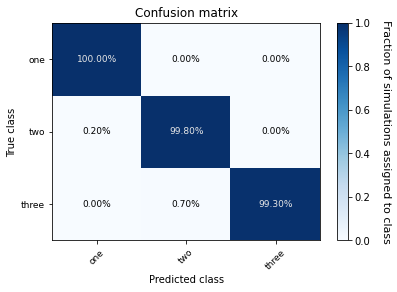

./testSims/Predictions/50BM_pred.csv
[[999   0   1]
 [  2 996   2]
 [  0   7 993]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


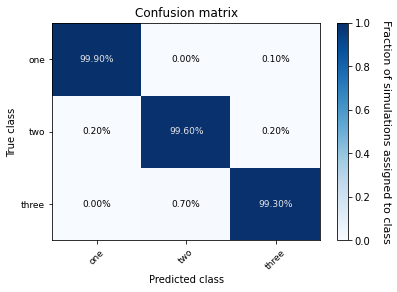

./testSims/Predictions/10BM_pred.csv
[[987   6   7]
 [ 31 932  37]
 [ 11  55 934]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


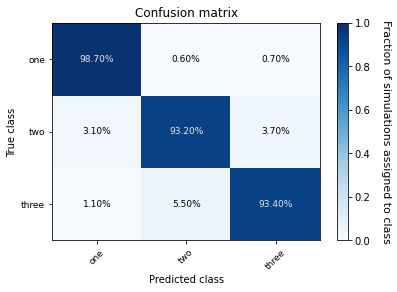

./testSims/Predictions/100OU_pred.csv
[[998   1   1]
 [  1 997   2]
 [  0   1 999]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


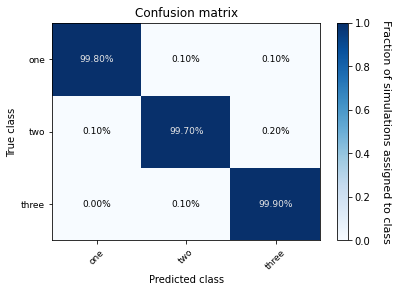

./testSims/Predictions/50OU_pred.csv
[[996   1   3]
 [  2 997   1]
 [  0   4 996]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


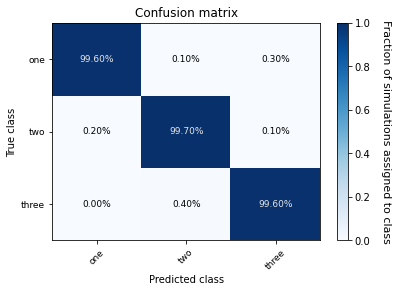

./testSims/Predictions/10OU_pred.csv
[[981  11   8]
 [ 29 929  42]
 [ 12  63 925]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


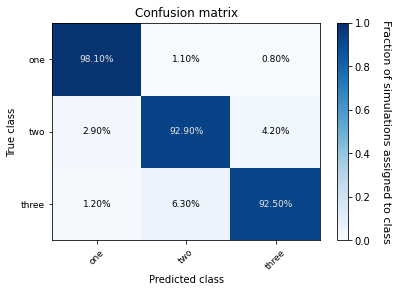

./testSims/Predictions/100disc_pred.csv
[[1000    0    0]
 [   0  999    1]
 [   0    1  999]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


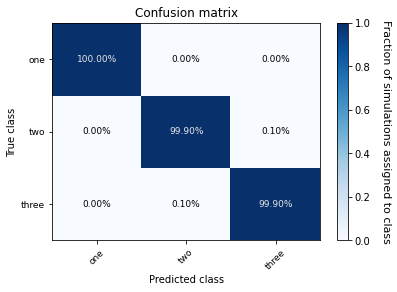

./testSims/Predictions/50disc_pred.csv
[[999   1   0]
 [  4 989   7]
 [  0  22 978]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


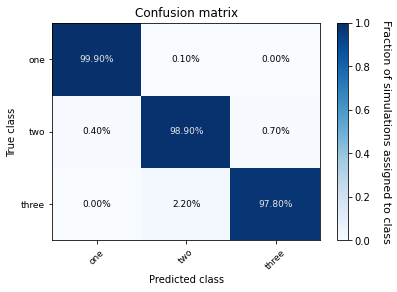

./testSims/Predictions/10disc_pred.csv
[[913  61  26]
 [100 809  91]
 [ 44 149 807]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


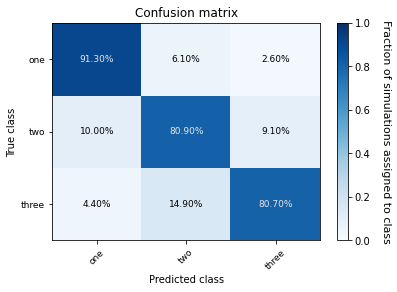

./testSims/Predictions/1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    1  999]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


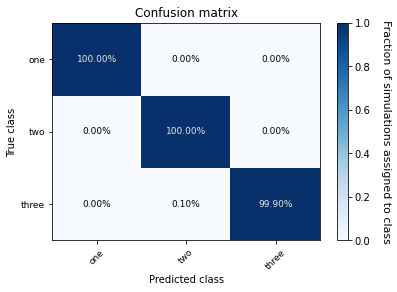

./testSims/Predictions/50SNPs_pred.csv
[[1000    0    0]
 [   4  996    0]
 [   1    7  992]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


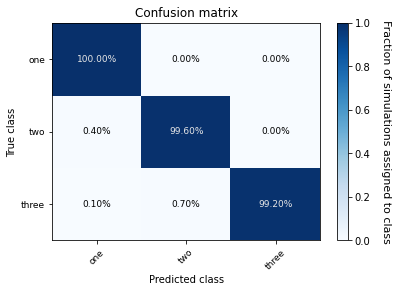

./testSims/Predictions/10SNPs_pred.csv
[[985   3  12]
 [ 82 885  33]
 [ 44 112 844]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


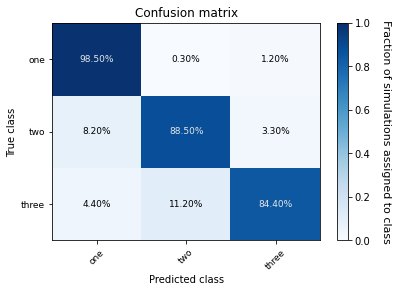

./testSims/Predictions/100BM_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    2  998]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


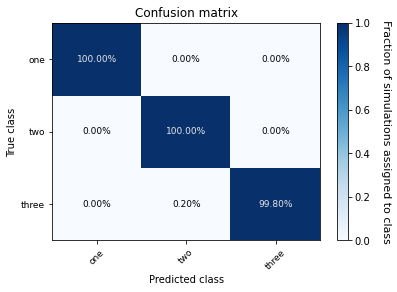

./testSims/Predictions/50BM_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


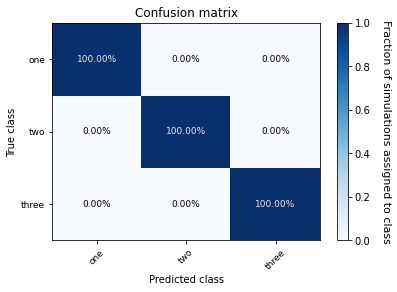

./testSims/Predictions/10BM_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


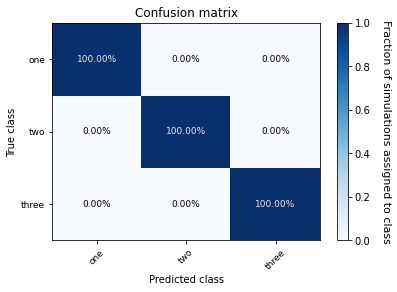

./testSims/Predictions/100BM_50SNPs_pred.csv
[[1000    0    0]
 [   1  999    0]
 [   0    2  998]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


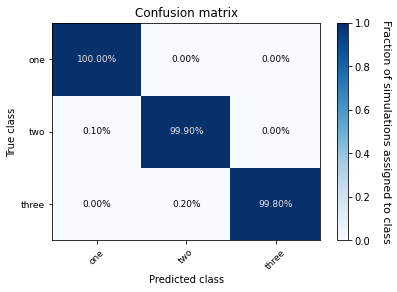

./testSims/Predictions/50BM_50SNPs_pred.csv
[[ 999    0    1]
 [   0 1000    0]
 [   0    3  997]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


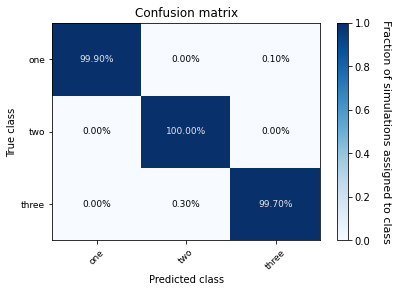

./testSims/Predictions/10BM_50SNPs_pred.csv
[[1000    0    0]
 [   3  996    1]
 [   0    3  997]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


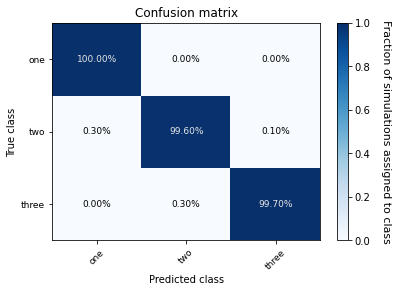

./testSims/Predictions/100BM_10SNPs_pred.csv
[[ 999    0    1]
 [   0 1000    0]
 [   0    3  997]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


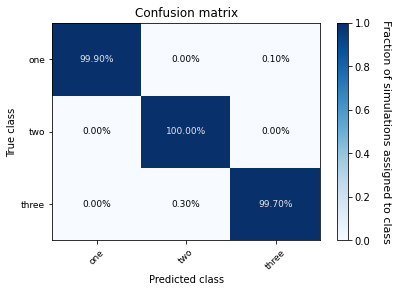

./testSims/Predictions/50BM_10SNPs_pred.csv
[[1000    0    0]
 [   0  999    1]
 [   0    6  994]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


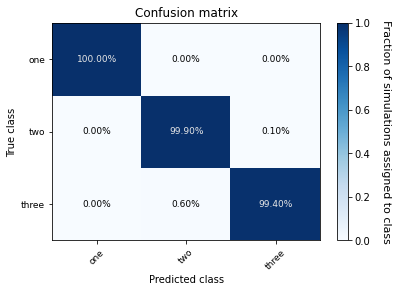

./testSims/Predictions/10BM_10SNPs_pred.csv
[[993   2   5]
 [ 16 968  16]
 [  3  29 968]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


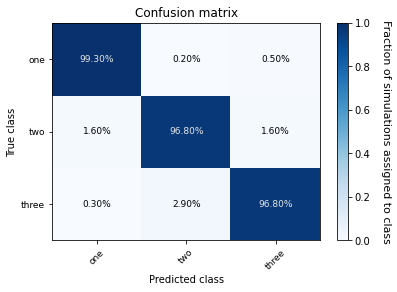

./testSims/Predictions/100OU_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


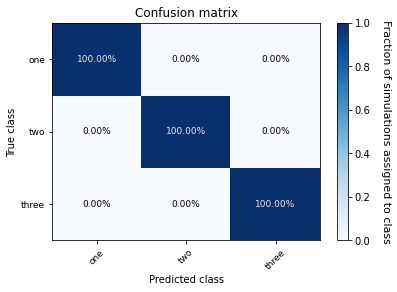

./testSims/Predictions/50OU_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    1  999]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


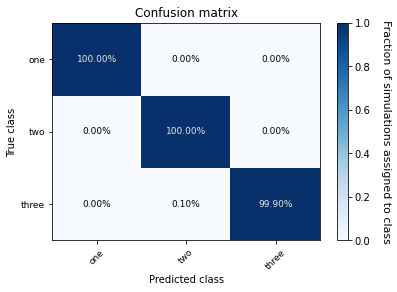

./testSims/Predictions/10OU_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    1  999]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


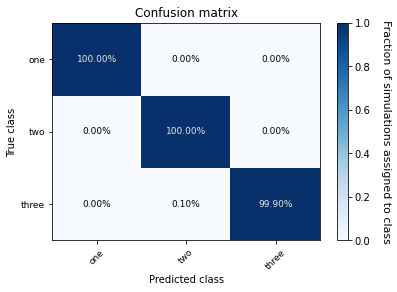

./testSims/Predictions/100OU_50SNPs_pred.csv
[[ 999    0    1]
 [   0  999    1]
 [   0    0 1000]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


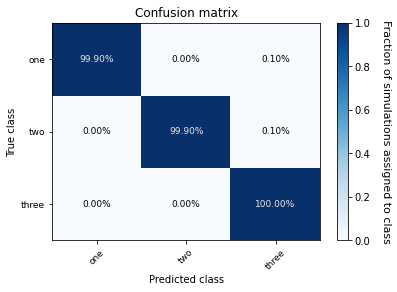

./testSims/Predictions/50OU_50SNPs_pred.csv
[[998   2   0]
 [  0 999   1]
 [  0   3 997]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


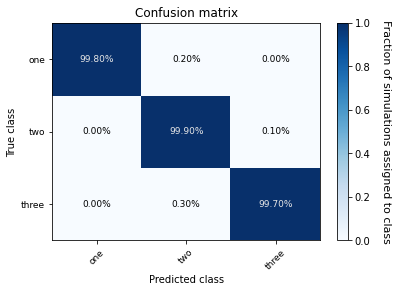

./testSims/Predictions/10OU_50SNPs_pred.csv
[[1000    0    0]
 [   3  997    0]
 [   0    3  997]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


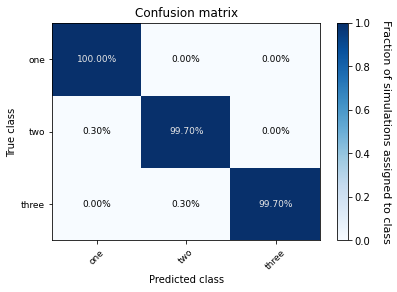

./testSims/Predictions/100OU_10SNPs_pred.csv
[[ 997    0    3]
 [   1  997    2]
 [   0    0 1000]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


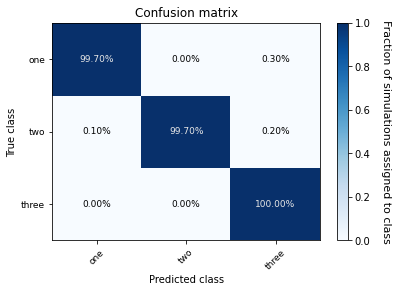

./testSims/Predictions/50OU_10SNPs_pred.csv
[[998   0   2]
 [  0 998   2]
 [  0   2 998]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


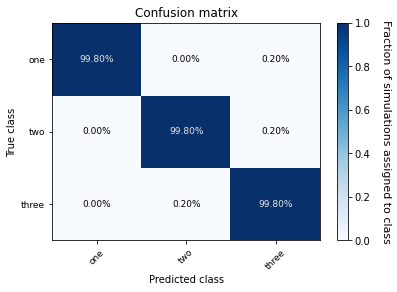

./testSims/Predictions/10OU_10SNPs_pred.csv
[[988   2  10]
 [ 16 939  45]
 [ 12  36 952]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


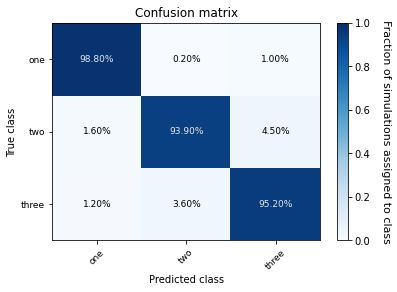

./testSims/Predictions/100disc_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


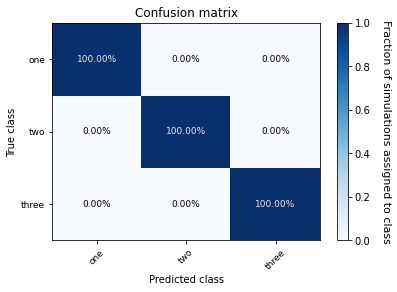

./testSims/Predictions/50disc_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    0 1000]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


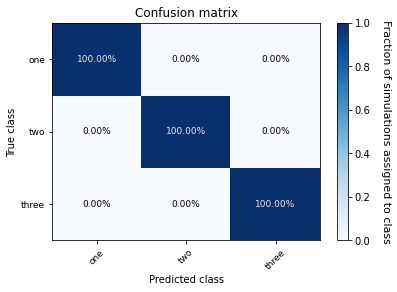

./testSims/Predictions/10disc_1KSNPs_pred.csv
[[1000    0    0]
 [   0 1000    0]
 [   0    1  999]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


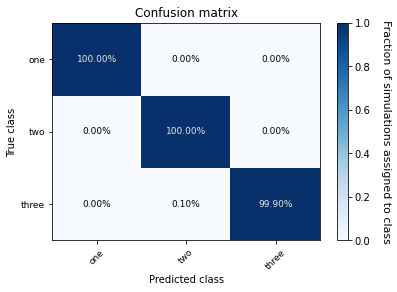

./testSims/Predictions/100disc_50SNPs_pred.csv
[[1000    0    0]
 [   1  998    1]
 [   0    1  999]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


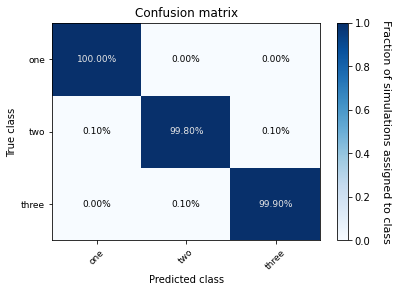

./testSims/Predictions/50disc_50SNPs_pred.csv
[[1000    0    0]
 [   1  999    0]
 [   0    2  998]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


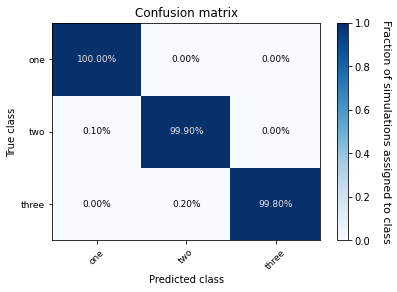

./testSims/Predictions/10disc_50SNPs_pred.csv
[[1000    0    0]
 [   4  994    2]
 [   0    3  997]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


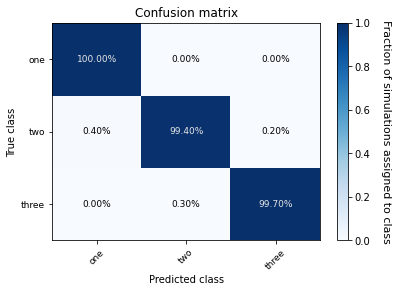

./testSims/Predictions/100disc_10SNPs_pred.csv
[[1000    0    0]
 [   1  999    0]
 [   1    1  998]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


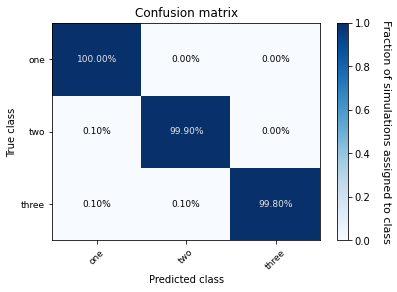

./testSims/Predictions/50disc_10SNPs_pred.csv
[[1000    0    0]
 [   1  998    1]
 [   1    7  992]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


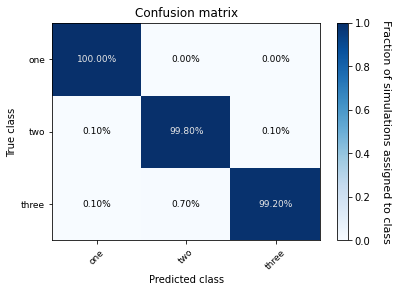

./testSims/Predictions/10disc_10SNPs_pred.csv
[[993   5   2]
 [ 43 918  39]
 [ 10  63 927]]


<ipython-input-5-5c6d1c09a4af>:16: MatplotlibDeprecationWarning: The 'cmap' parameter to Colorbar has no effect because it is overridden by the mappable; it is deprecated since 3.3 and will be removed two minor releases later.
  cbar = plt.colorbar(heatmap, cmap=plt.cm.Blues, ax=ax)


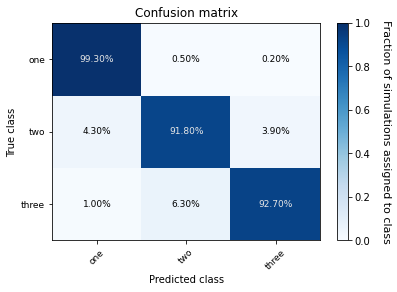

In [6]:
# Now we will plot the confusion matrices for each trained model
pred = model1.predict(np.swapaxes(traits_BM, 1, 2))
confusion_save(pred, './testSims/Predictions/100BM_pred.csv')

# get the predictions for the next dataset
pred = model2.predict(np.swapaxes(traits_BM50, 1, 2))
confusion_save(pred, './testSims/Predictions/50BM_pred.csv')

# get the predictions for the next dataset
pred = model3.predict(np.swapaxes(traits_BM10, 1, 2))
confusion_save(pred, './testSims/Predictions/10BM_pred.csv')

# get the predictions
pred = model4.predict(np.swapaxes(traits_OU, 1, 2))
confusion_save(pred, './testSims/Predictions/100OU_pred.csv')

# get the predictions
pred = model5.predict(np.swapaxes(traits_OU50, 1, 2))
confusion_save(pred, './testSims/Predictions/50OU_pred.csv')

# get the predictions
pred = model6.predict(np.swapaxes(traits_OU10, 1, 2))
confusion_save(pred, './testSims/Predictions/10OU_pred.csv')

# get the predictions
pred = model7.predict(np.swapaxes(traits_disc, 1, 2))
confusion_save(pred, './testSims/Predictions/100disc_pred.csv')

# get the predictions
pred = model8.predict(np.swapaxes(traits_disc50, 1, 2))
confusion_save(pred, './testSims/Predictions/50disc_pred.csv')

# get the predictions
pred = model9.predict(np.swapaxes(traits_disc10, 1, 2))
confusion_save(pred, './testSims/Predictions/10disc_pred.csv')

# get the predictions
pred = model10.predict(xtest)
confusion_save(pred, './testSims/Predictions/1KSNPs_pred.csv')

# get the predictions
pred = model11.predict(xtest[:,0:50,:])
confusion_save(pred, './testSims/Predictions/50SNPs_pred.csv')

# get the predictions
pred = model12.predict(xtest[:,0:10,:])
confusion_save(pred, './testSims/Predictions/10SNPs_pred.csv')

# get the predictions
pred = model13.predict([np.swapaxes(traits_BM, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/100BM_1KSNPs_pred.csv')

# get the predictions
pred = model14.predict([np.swapaxes(traits_BM50, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/50BM_1KSNPs_pred.csv')

# get the predictions
pred = model15.predict([np.swapaxes(traits_BM10, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/10BM_1KSNPs_pred.csv')

# get the predictions
pred = model16.predict([np.swapaxes(traits_BM, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/100BM_50SNPs_pred.csv')

# get the predictions
pred = model17.predict([np.swapaxes(traits_BM50, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/50BM_50SNPs_pred.csv')

# get the predictions
pred = model18.predict([np.swapaxes(traits_BM10, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/10BM_50SNPs_pred.csv')

# get the predictions
pred = model19.predict([np.swapaxes(traits_BM, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/100BM_10SNPs_pred.csv')

# get the predictions
pred = model20.predict([np.swapaxes(traits_BM50, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/50BM_10SNPs_pred.csv')

# get the predictions
pred = model21.predict([np.swapaxes(traits_BM10, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/10BM_10SNPs_pred.csv')

# get the predictions
pred = model22.predict([np.swapaxes(traits_OU, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/100OU_1KSNPs_pred.csv')

# get the predictions
pred = model23.predict([np.swapaxes(traits_OU50, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/50OU_1KSNPs_pred.csv')

# get the predictions
pred = model24.predict([np.swapaxes(traits_OU10, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/10OU_1KSNPs_pred.csv')

# get the predictions
pred = model25.predict([np.swapaxes(traits_OU, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/100OU_50SNPs_pred.csv')

# get the predictions
pred = model26.predict([np.swapaxes(traits_OU50, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/50OU_50SNPs_pred.csv')

# get the predictions
pred = model27.predict([np.swapaxes(traits_OU10, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/10OU_50SNPs_pred.csv')

# get the predictions
pred = model28.predict([np.swapaxes(traits_OU, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/100OU_10SNPs_pred.csv')

# get the predictions
pred = model29.predict([np.swapaxes(traits_OU50, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/50OU_10SNPs_pred.csv')

# get the predictions
pred = model30.predict([np.swapaxes(traits_OU10, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/10OU_10SNPs_pred.csv')

# get the predictions
pred = model31.predict([np.swapaxes(traits_disc, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/100disc_1KSNPs_pred.csv')

# get the predictions
pred = model32.predict([np.swapaxes(traits_disc50, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/50disc_1KSNPs_pred.csv')

# get the predictions
pred = model33.predict([np.swapaxes(traits_disc10, 1, 2), xtest])
confusion_save(pred, './testSims/Predictions/10disc_1KSNPs_pred.csv')

# get the predictions
pred = model34.predict([np.swapaxes(traits_disc, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/100disc_50SNPs_pred.csv')

# get the predictions
pred = model35.predict([np.swapaxes(traits_disc50, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/50disc_50SNPs_pred.csv')

# get the predictions
pred = model36.predict([np.swapaxes(traits_disc10, 1, 2), xtest[:,0:50,:]])
confusion_save(pred, './testSims/Predictions/10disc_50SNPs_pred.csv')

# get the predictions
pred = model37.predict([np.swapaxes(traits_disc, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/100disc_10SNPs_pred.csv')

# get the predictions
pred = model38.predict([np.swapaxes(traits_disc50, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/50disc_10SNPs_pred.csv')

# get the predictions
pred = model39.predict([np.swapaxes(traits_disc10, 1, 2), xtest[:,0:10,:]])
confusion_save(pred, './testSims/Predictions/10disc_10SNPs_pred.csv')